# IntelliFlow — Traffic Prediction: Full Model Benchmark

**AI-Enabled Real-Time Urban Traffic Prediction & Route Optimization Platform**

This notebook is the complete ML layer. It:

1. Loads & audits the Bengaluru traffic dataset
2. Produces a full EDA visual report
3. Engineers leakage-safe forecasting features (writes a reusable `features.py`)
4. Trains **every practical algorithm** for two tasks
5. Compares them on a held-out time window and **auto-selects the winner**
6. Saves every artifact the Django backend needs

---

### The two tasks

| Task | Type | Target |
|---|---|---|
| **A** | Regression | Next-day `Traffic Volume` for an intersection |
| **B** | Classification | Next-day `Congestion Class` (low / moderate / high / severe) |

### The one rule that matters

The dataset is **daily** granularity, and several columns (`Congestion Level`,
`Travel Time Index`, `Road Capacity Utilization`, `Average Speed`) are all measuring
the *same underlying thing* on the same row. Feeding them in raw to predict congestion
gives ~99% accuracy that is pure **leakage** and collapses the moment it hits real data.

So this notebook forecasts **day t+1 using only data up to day t**. Every score you see
is honest. An explicit assertion enforces it.

---
*Run top-to-bottom on a fresh kernel. No manual edits needed.*

## 0 · Configuration & Imports

In [ ]:
# If anything is missing, uncomment and run once:
# !pip install pandas numpy scikit-learn xgboost lightgbm catboost matplotlib seaborn joblib holidays tensorflow

In [1]:
import os, json, time, warnings, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)

# ─────────────────────────── CONFIG ───────────────────────────
RANDOM_STATE = 42
DATA_PATH    = Path("dataset/Banglore_traffic_Dataset.csv")   # <- your CSV
ART          = Path("artifacts")

# Time-based split fractions (never random-shuffle time series)
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

# Toggle heavy models off if you're on a small machine
RUN_SVM   = True    # SVC/SVR — slowest of the classical models
RUN_MLP   = True    # sklearn neural net
RUN_LSTM  = True    # needs tensorflow
LSTM_EPOCHS   = 60
LSTM_SEQ_LEN  = 14

# Tuning: how many random hyperparameter combos for the top tree models
TUNE_ITER = 20
TUNE_TOP_MODELS = True   # set False for a fast first pass
# ──────────────────────────────────────────────────────────────

for p in ["models", "encoders", "metadata", "figures"]:
    (ART / p).mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)

# Consistent, colourblind-safe plotting identity
PALETTE   = ["#2E86AB", "#F5A623", "#E8590C", "#C92A2A", "#2ECC71", "#7048E8"]
CONG_COLS = {"low": "#2ECC71", "moderate": "#F5A623",
             "high": "#E8590C", "severe": "#C92A2A"}
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

def savefig(name):
    plt.savefig(ART / "figures" / f"{name}.png")
    plt.show()

print("Python      :", platform.python_version())
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)

Python      : 3.10.11
pandas      : 2.3.3
numpy       : 2.2.6
scikit-learn: 1.6.1


In [2]:
# Optional libraries — everything degrades gracefully if absent
HAS = {}

try:
    from xgboost import XGBClassifier, XGBRegressor
    import xgboost; HAS["xgboost"] = xgboost.__version__
except Exception as e:
    HAS["xgboost"] = None; print("xgboost unavailable:", e)

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    import lightgbm; HAS["lightgbm"] = lightgbm.__version__
except Exception:
    HAS["lightgbm"] = None

try:
    from catboost import CatBoostClassifier, CatBoostRegressor
    import catboost; HAS["catboost"] = catboost.__version__
except Exception:
    HAS["catboost"] = None

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS["tensorflow"] = tf.__version__
    tf.random.set_seed(RANDOM_STATE)
    tf.get_logger().setLevel("ERROR")
except Exception:
    HAS["tensorflow"] = None

try:
    import holidays as _hol; HAS["holidays"] = _hol.__version__
except Exception:
    HAS["holidays"] = None

for k, v in HAS.items():
    print(f"  {k:12s} {v if v else '— not installed (will be skipped)'}")

  xgboost      3.1.1
  lightgbm     4.6.0
  catboost     — not installed (will be skipped)
  tensorflow   2.20.0
  holidays     — not installed (will be skipped)


---
## 1 · Load, Audit & Clean

In [3]:
assert DATA_PATH.exists(), f"CSV not found at {DATA_PATH.resolve()}"

raw = pd.read_csv(DATA_PATH)
raw["Date"] = pd.to_datetime(raw["Date"])

print("="*72)
print("RAW DATASET AUDIT")
print("="*72)
print(f"Shape          : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Memory         : {raw.memory_usage(deep=True).sum()/1e6:.2f} MB")
print(f"Date range     : {raw['Date'].min().date()}  ->  {raw['Date'].max().date()}"
      f"  ({(raw['Date'].max()-raw['Date'].min()).days+1} days)")
print(f"Areas          : {raw['Area Name'].nunique()}")
print(f"Intersections  : {raw['Road/Intersection Name'].nunique()}")
print(f"Duplicate rows : {raw.duplicated().sum()}")
print("\nDtypes & nulls:")
print(pd.DataFrame({"dtype": raw.dtypes.astype(str),
                    "nulls": raw.isna().sum(),
                    "null_%": (raw.isna().mean()*100).round(2)}))

RAW DATASET AUDIT
Shape          : 8,936 rows x 16 columns
Memory         : 3.18 MB
Date range     : 2022-01-01  ->  2024-08-09  (952 days)
Areas          : 8
Intersections  : 16
Duplicate rows : 0

Dtypes & nulls:
                                             dtype  nulls  null_%
Date                                datetime64[ns]      0     0.0
Area Name                                   object      0     0.0
Road/Intersection Name                      object      0     0.0
Traffic Volume                               int64      0     0.0
Average Speed                              float64      0     0.0
Travel Time Index                          float64      0     0.0
Congestion Level                           float64      0     0.0
Road Capacity Utilization                  float64      0     0.0
Incident Reports                             int64      0     0.0
Environmental Impact                       float64      0     0.0
Public Transport Usage                     float64      0  

In [4]:
raw["intersection_id"] = raw["Area Name"].str.strip() + "::" + raw["Road/Intersection Name"].str.strip()

per_int = (raw.groupby(["Area Name", "Road/Intersection Name"])
             .agg(rows=("Date", "size"),
                  first=("Date", "min"), last=("Date", "max"),
                  avg_volume=("Traffic Volume", "mean"),
                  avg_congestion=("Congestion Level", "mean"))
             .sort_values("rows", ascending=False).round(1))
print(f"{len(per_int)} unique intersections\n")
print(per_int.to_string())

16 unique intersections

                                        rows      first       last  avg_volume  avg_congestion
Area Name       Road/Intersection Name                                                        
Indiranagar     100 Feet Road            860 2022-01-01 2024-08-09     31956.9            87.1
                CMH Road                 860 2022-01-01 2024-08-09     32611.9            88.2
M.G. Road       Anil Kumble Circle       759 2022-01-01 2024-08-09     35251.8            90.8
                Trinity Circle           742 2022-01-01 2024-08-09     35350.1            90.4
Koramangala     Sony World Junction      684 2022-01-01 2024-08-09     41470.8            94.1
                Sarjapur Road            680 2022-01-01 2024-08-09     40190.0            93.8
Jayanagar       South End Circle         593 2022-01-01 2024-08-09     24704.1            77.3
                Jayanagar 4th Block      580 2022-01-01 2024-08-08     24496.2            76.7
Whitefield      Marathaha

In [5]:
# ── Date-continuity check (lags must mean 'N days ago', not 'N rows ago')
gaps = []
for iid, g in raw.groupby("intersection_id"):
    dts = pd.Series(sorted(g["Date"].unique()))
    expected = (dts.iloc[-1] - dts.iloc[0]).days + 1
    if len(dts) != expected:
        d = dts.diff().dt.days.dropna()
        gaps.append({"intersection": iid, "have": len(dts), "expect": expected,
                     "missing": expected - len(dts), "largest_gap_days": int(d.max())})
if gaps:
    print("Date gaps found (will be reindexed + interpolated, and flagged):")
    print(pd.DataFrame(gaps).to_string(index=False))
else:
    print("✅ No date gaps — every intersection has a continuous daily series.")

Date gaps found (will be reindexed + interpolated, and flagged):
                        intersection  have  expect  missing  largest_gap_days
         Electronic City::Hosur Road   277     945      668                15
Electronic City::Silk Board Junction   275     945      670                17
                Hebbal::Ballari Road   476     951      475                11
              Hebbal::Hebbal Flyover   474     951      477                 8
          Indiranagar::100 Feet Road   860     952       92                 3
               Indiranagar::CMH Road   860     952       92                 4
      Jayanagar::Jayanagar 4th Block   580     951      371                 8
         Jayanagar::South End Circle   593     952      359                 7
          Koramangala::Sarjapur Road   680     952      272                 6
    Koramangala::Sony World Junction   684     952      268                 8
       M.G. Road::Anil Kumble Circle   759     952      193                 5

In [6]:
# ── The saturation problem: how much of the target is pinned at the ceiling?
sat_c = (raw["Congestion Level"] >= 99.99).mean()
sat_u = (raw["Road Capacity Utilization"] >= 99.99).mean()
sat_t = (raw["Travel Time Index"] >= 1.4999).mean()

print("="*72)
print("CEILING SATURATION  (drives class balance & metric choice)")
print("="*72)
print(f"Congestion Level     == 100.0 : {sat_c:6.2%}")
print(f"Capacity Utilization == 100.0 : {sat_u:6.2%}")
print(f"Travel Time Index    ==   1.5 : {sat_t:6.2%}")
print("\nThese three columns are clipped at a hard ceiling, so a large block of rows")
print("is literally indistinguishable at the top end. Expect a dominant 'severe'")
print("class -> always read macro-F1 next to raw accuracy.")

CEILING SATURATION  (drives class balance & metric choice)
Congestion Level     == 100.0 : 43.48%
Capacity Utilization == 100.0 : 73.69%
Travel Time Index    ==   1.5 : 58.48%

These three columns are clipped at a hard ceiling, so a large block of rows
is literally indistinguishable at the top end. Expect a dominant 'severe'
class -> always read macro-F1 next to raw accuracy.


---
## 2 · Exploratory Data Analysis

14 figures, all saved to `artifacts/figures/`. Each has a short read-out of what it
means for modelling.

In [7]:
CONG_BINS   = [-np.inf, 40.0, 65.0, 85.0, np.inf]
CONG_LABELS = ["low", "moderate", "high", "severe"]
raw["congestion_class"] = pd.cut(raw["Congestion Level"], bins=CONG_BINS,
                                 labels=CONG_LABELS, right=False)

NUM_COLS = ["Traffic Volume", "Average Speed", "Travel Time Index", "Congestion Level",
            "Road Capacity Utilization", "Incident Reports", "Environmental Impact",
            "Public Transport Usage", "Traffic Signal Compliance", "Parking Usage",
            "Pedestrian and Cyclist Count"]
print(raw[NUM_COLS].describe().T.round(2).to_string())

                               count      mean       std      min       25%       50%       75%       max
Traffic Volume                8936.0  29236.05  13001.81  4233.00  19413.00  27600.00  38058.50  72039.00
Average Speed                 8936.0     39.45     10.71    20.00     31.78     39.20     46.64     89.79
Travel Time Index             8936.0      1.38      0.17     1.00      1.24      1.50      1.50      1.50
Congestion Level              8936.0     80.82     23.53     5.16     64.29     92.39    100.00    100.00
Road Capacity Utilization     8936.0     92.03     16.58    18.74     97.35    100.00    100.00    100.00
Incident Reports              8936.0      1.57      1.42     0.00      0.00      1.00      2.00     10.00
Environmental Impact          8936.0    108.47     26.00    58.47     88.83    105.20    126.12    194.08
Public Transport Usage        8936.0     45.09     20.21    10.01     27.34     45.17     62.43     79.98
Traffic Signal Compliance     8936.0     79.95

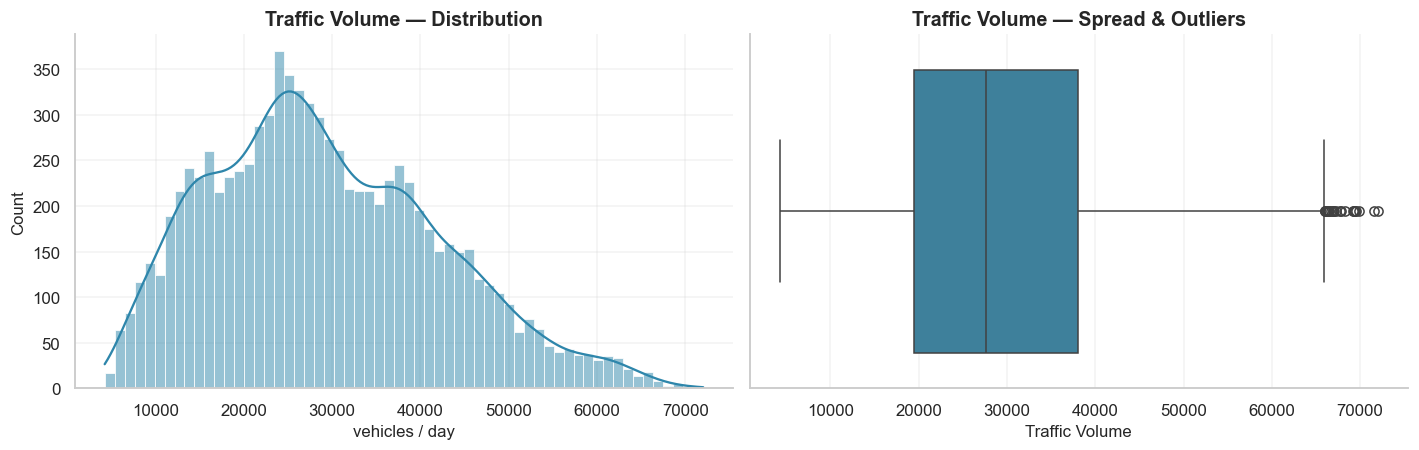

skew=0.46  kurtosis=-0.30


In [8]:
# ── Fig 1: Traffic volume distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(raw["Traffic Volume"], bins=60, kde=True, color=PALETTE[0], ax=ax[0])
ax[0].set_title("Traffic Volume — Distribution"); ax[0].set_xlabel("vehicles / day")
sns.boxplot(x=raw["Traffic Volume"], color=PALETTE[0], ax=ax[1])
ax[1].set_title("Traffic Volume — Spread & Outliers")
plt.tight_layout(); savefig("01_traffic_volume_distribution")
print(f"skew={raw['Traffic Volume'].skew():.2f}  "
      f"kurtosis={raw['Traffic Volume'].kurtosis():.2f}")

*Read-out:* heavy right tail means tree ensembles will beat linear models on the regression task, and MAPE will be the fairer error metric than raw RMSE.

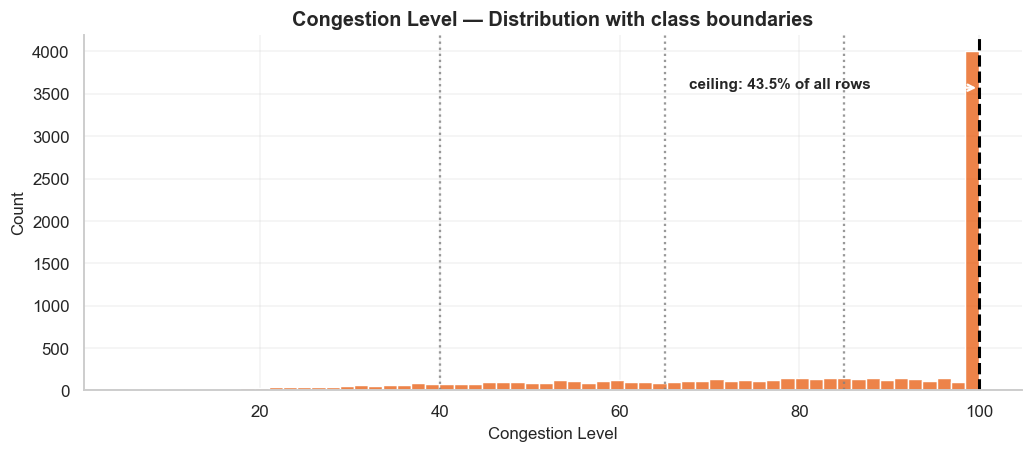

In [9]:
# ── Fig 2: Congestion distribution + the ceiling spike
fig, ax = plt.subplots(figsize=(11, 4.2))
sns.histplot(raw["Congestion Level"], bins=60, color=PALETTE[2], ax=ax)
ax.axvline(100, ls="--", lw=2, color="black")
ax.annotate(f"ceiling: {sat_c:.1%} of all rows", xy=(100, ax.get_ylim()[1]*0.85),
            xytext=(-190, 0), textcoords="offset points", fontweight="bold",
            arrowprops=dict(arrowstyle="->", lw=1.5))
for b in CONG_BINS[1:-1]:
    ax.axvline(b, ls=":", color="grey", alpha=0.8)
ax.set_title("Congestion Level — Distribution with class boundaries")
savefig("02_congestion_distribution")

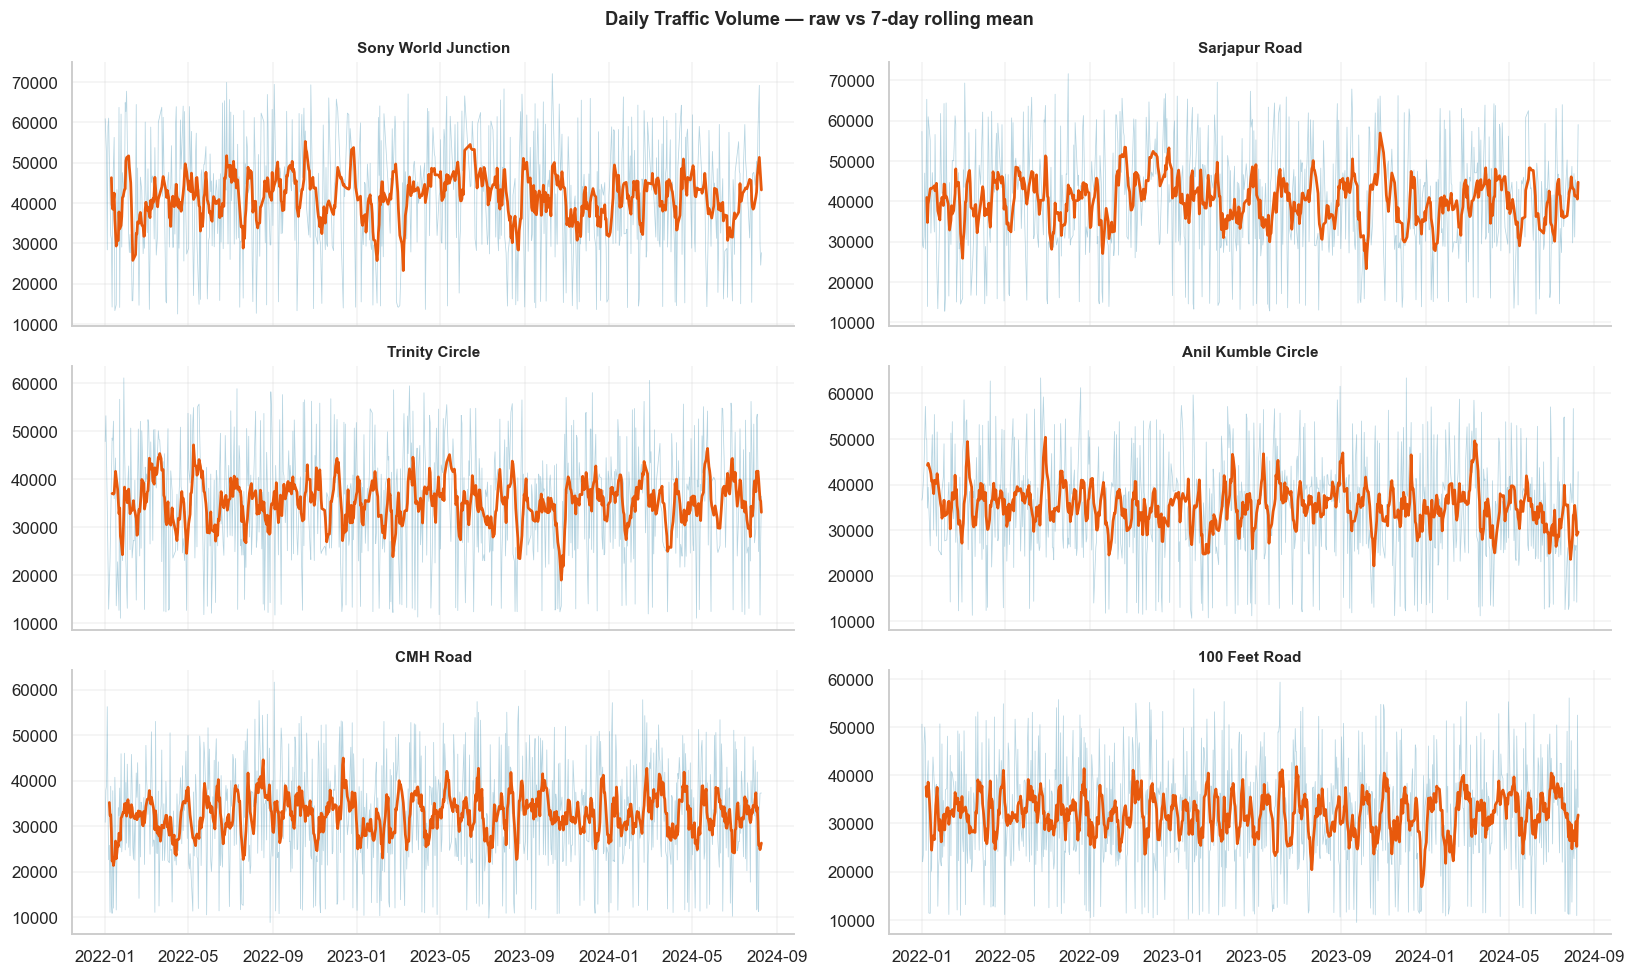

In [10]:
# ── Fig 3: Daily series for the busiest intersections
top6 = raw.groupby("intersection_id")["Traffic Volume"].mean().nlargest(6).index
fig, axes = plt.subplots(3, 2, figsize=(15, 9), sharex=True)
for ax, iid in zip(axes.ravel(), top6):
    g = raw[raw.intersection_id == iid].sort_values("Date")
    ax.plot(g["Date"], g["Traffic Volume"], lw=0.5, alpha=0.35, color=PALETTE[0])
    ax.plot(g["Date"], g["Traffic Volume"].rolling(7).mean(), lw=1.8, color=PALETTE[2])
    ax.set_title(iid.split("::")[-1], fontsize=10)
fig.suptitle("Daily Traffic Volume — raw vs 7-day rolling mean", fontweight="bold")
plt.tight_layout(); savefig("03_timeseries_by_intersection")

*Read-out:* the rolling mean tracks the raw series closely — traffic is strongly autocorrelated, so lag and rolling features should carry most of the predictive signal.

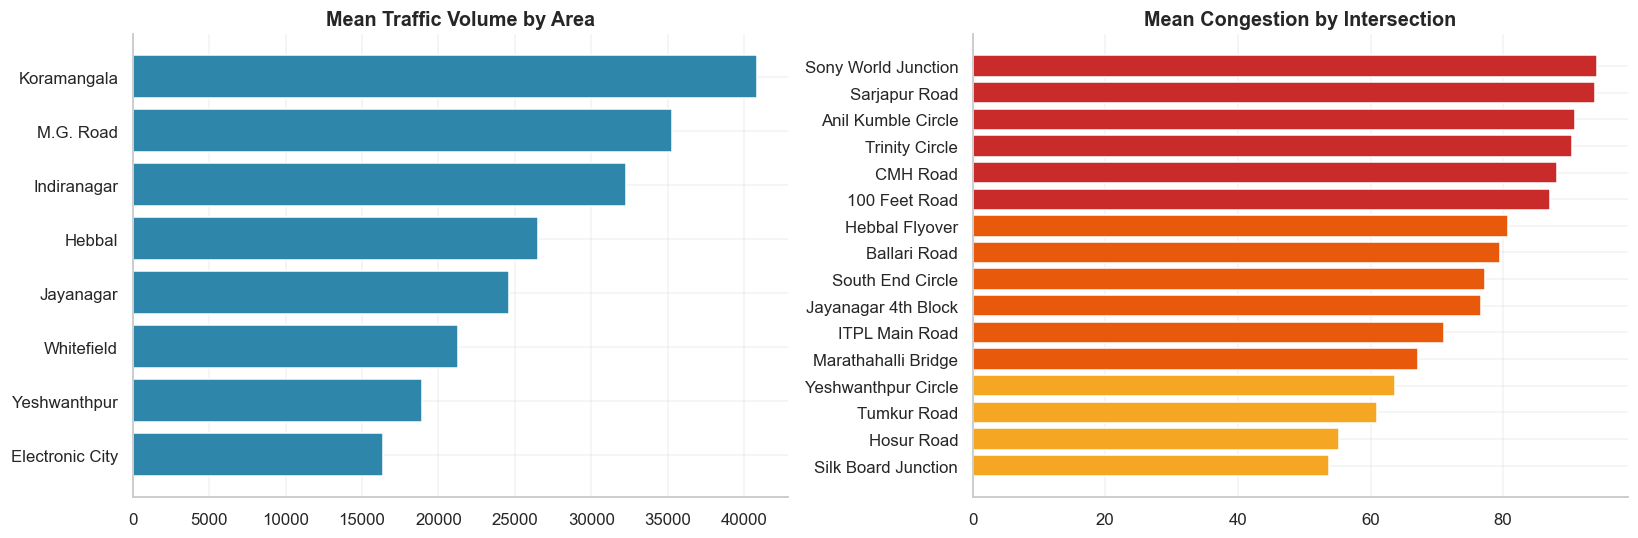

In [11]:
# ── Fig 4 & 5: Area and intersection rankings
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
a = raw.groupby("Area Name")["Traffic Volume"].mean().sort_values()
ax[0].barh(a.index, a.values, color=PALETTE[0]); ax[0].set_title("Mean Traffic Volume by Area")
c = raw.groupby("intersection_id")["Congestion Level"].mean().sort_values()
cols = [CONG_COLS[pd.cut([v], bins=CONG_BINS, labels=CONG_LABELS, right=False)[0]] for v in c.values]
ax[1].barh([i.split("::")[-1] for i in c.index], c.values, color=cols)
ax[1].set_title("Mean Congestion by Intersection")
plt.tight_layout(); savefig("04_05_area_intersection_rankings")

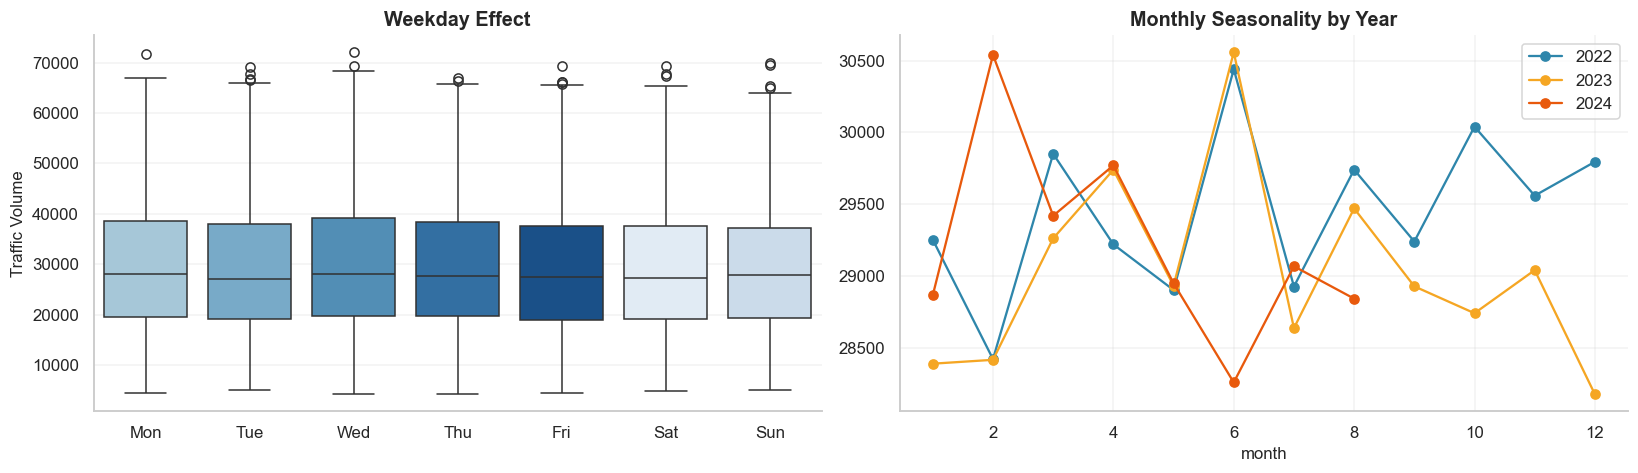

In [12]:
# ── Fig 6 & 7: Weekly and monthly seasonality
raw["dow"] = raw["Date"].dt.day_name().str[:3]
raw["month"] = raw["Date"].dt.month
order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, ax = plt.subplots(1, 2, figsize=(15, 4.4))
sns.boxplot(data=raw, x="dow", y="Traffic Volume", order=order,
            hue="dow", legend=False, palette="Blues", ax=ax[0])
ax[0].set_title("Weekday Effect"); ax[0].set_xlabel("")
for yr, g in raw.groupby(raw["Date"].dt.year):
    ax[1].plot(g.groupby("month")["Traffic Volume"].mean(), marker="o", label=str(yr))
ax[1].set_title("Monthly Seasonality by Year"); ax[1].set_xlabel("month"); ax[1].legend()
plt.tight_layout(); savefig("06_07_seasonality")

*Read-out:* a clear weekend drop justifies `is_weekend` + cyclical day-of-week encodings; the year-over-year monthly curves justify `month_sin/cos`.

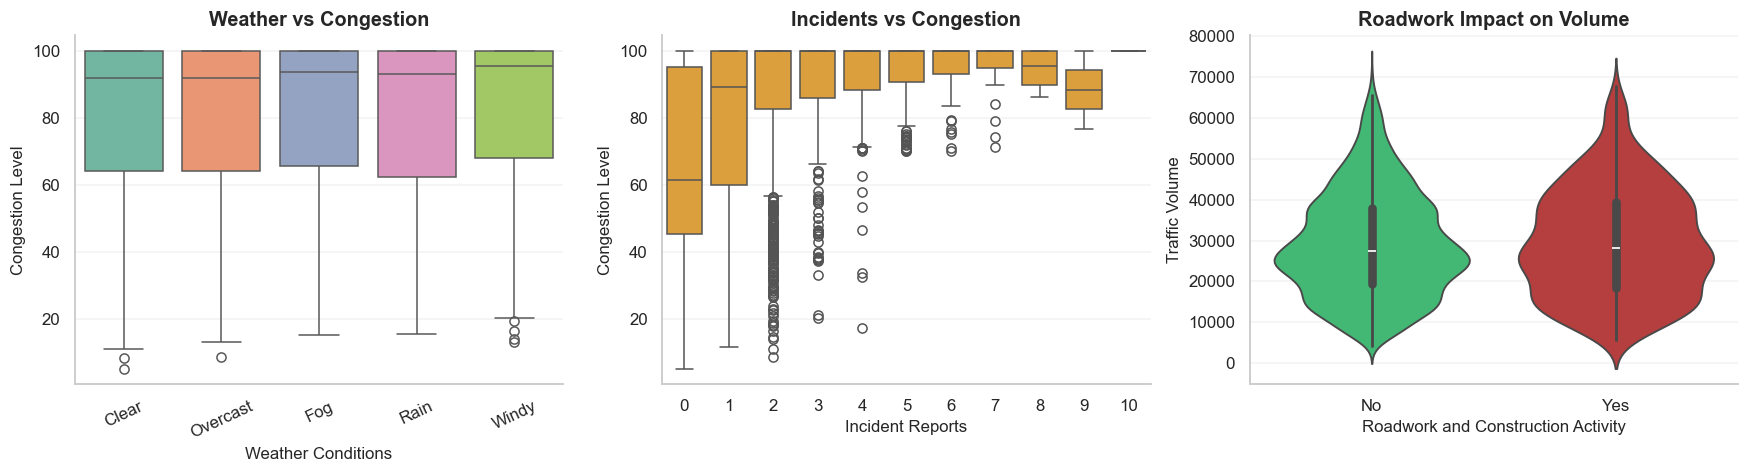

In [13]:
# ── Fig 8, 9, 10: Weather, incidents, roadwork
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
sns.boxplot(data=raw, x="Weather Conditions", y="Congestion Level",
            hue="Weather Conditions", legend=False, palette="Set2", ax=ax[0])
ax[0].set_title("Weather vs Congestion"); ax[0].tick_params(axis="x", rotation=25)
sns.boxplot(data=raw, x="Incident Reports", y="Congestion Level",
            color=PALETTE[1], ax=ax[1])
ax[1].set_title("Incidents vs Congestion")
sns.violinplot(data=raw, x="Roadwork and Construction Activity", y="Traffic Volume",
               hue="Roadwork and Construction Activity", legend=False,
               palette=[PALETTE[4], PALETTE[3]], ax=ax[2])
ax[2].set_title("Roadwork Impact on Volume")
plt.tight_layout(); savefig("08_09_10_context_effects")

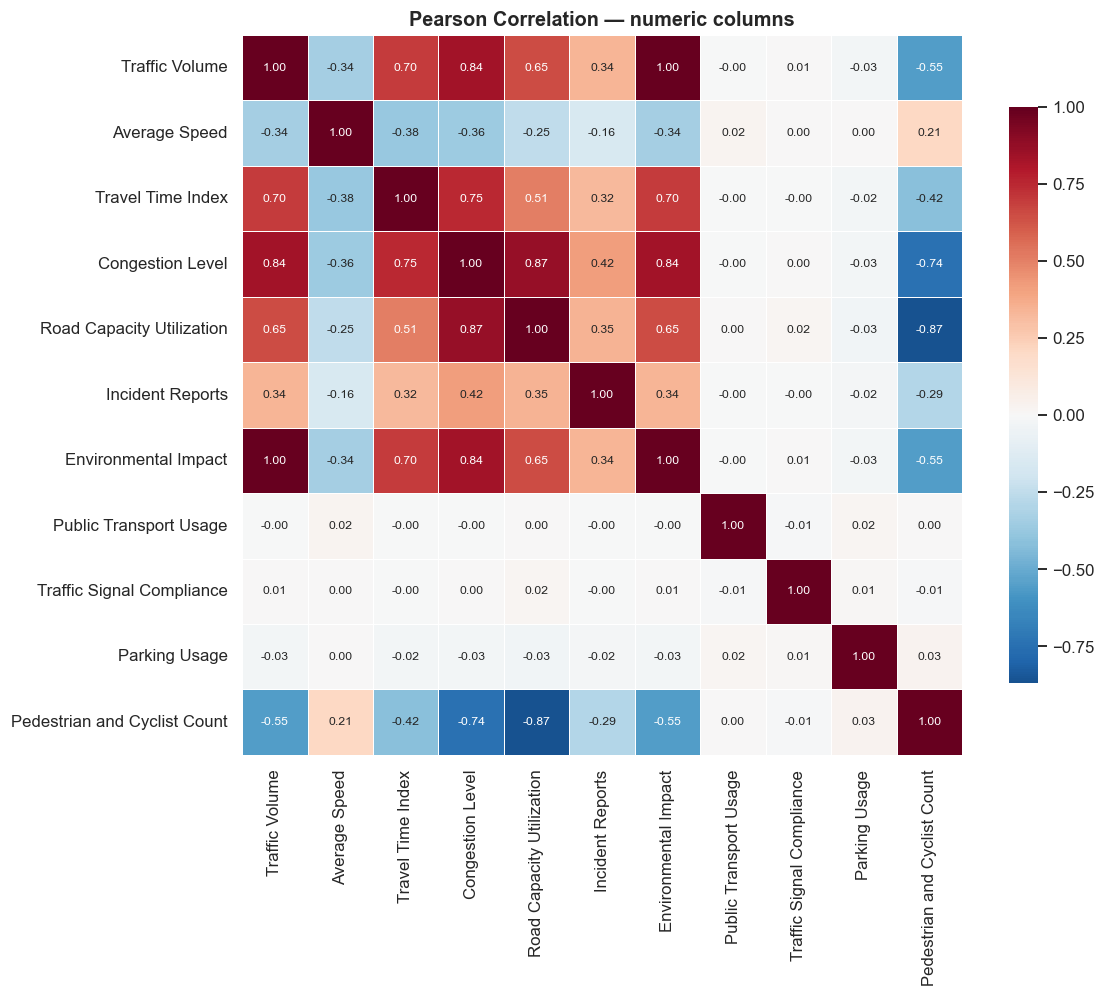


Near-collinear pairs (|r| > 0.75) — these are the leakage risks:
   Traffic Volume                 <-> Congestion Level               r = +0.837
   Traffic Volume                 <-> Environmental Impact           r = +1.000
   Travel Time Index              <-> Congestion Level               r = +0.752
   Congestion Level               <-> Road Capacity Utilization      r = +0.865
   Congestion Level               <-> Environmental Impact           r = +0.837
   Road Capacity Utilization      <-> Pedestrian and Cyclist Count   r = -0.868


In [14]:
# ── Fig 11: Correlation heatmap — this justifies the leakage guard
plt.figure(figsize=(11, 8.5))
corr = raw[NUM_COLS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=.5, annot_kws={"size": 8},
            cbar_kws={"shrink": .8})
plt.title("Pearson Correlation — numeric columns")
savefig("11_correlation_heatmap")

print("\nNear-collinear pairs (|r| > 0.75) — these are the leakage risks:")
seen = set()
for a in NUM_COLS:
    for b in NUM_COLS:
        if a != b and (b, a) not in seen and abs(corr.loc[a, b]) > 0.75:
            seen.add((a, b)); print(f"   {a:30s} <-> {b:30s} r = {corr.loc[a,b]:+.3f}")

*Read-out:* `Congestion Level`, `Road Capacity Utilization`, `Travel Time Index` and
`Average Speed` are near-collinear — they are four views of one quantity measured on
the same row. **This is exactly why they may only enter the model in lagged form.**

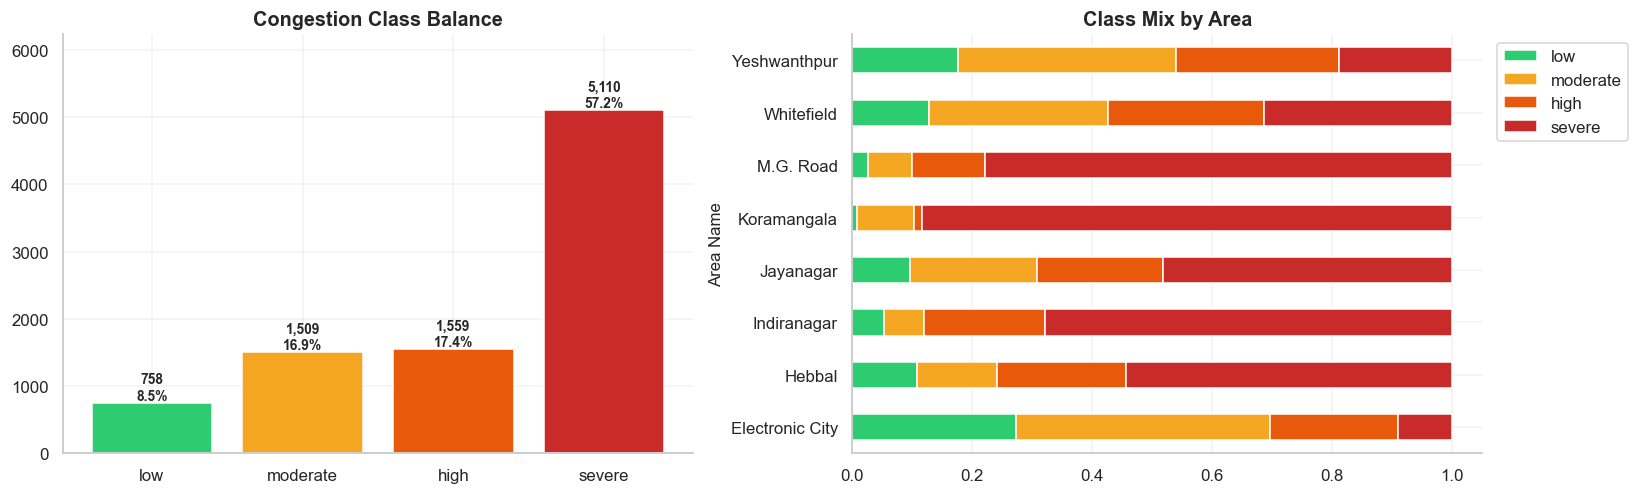

Imbalance ratio (largest/smallest class): 6.7x
-> class_weight='balanced' is enabled where supported; macro-F1 is reported everywhere.


In [15]:
# ── Fig 12 & 13: Class balance and per-area class mix
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
vc = raw["congestion_class"].value_counts().reindex(CONG_LABELS)
bars = ax[0].bar(vc.index, vc.values, color=[CONG_COLS[c] for c in vc.index])
for b, v in zip(bars, vc.values):
    ax[0].text(b.get_x()+b.get_width()/2, v, f"{v:,}\n{v/len(raw):.1%}",
               ha="center", va="bottom", fontsize=9, fontweight="bold")
ax[0].set_title("Congestion Class Balance"); ax[0].set_ylim(0, vc.max()*1.22)
ct = pd.crosstab(raw["Area Name"], raw["congestion_class"], normalize="index")[CONG_LABELS]
ct.plot(kind="barh", stacked=True, color=[CONG_COLS[c] for c in CONG_LABELS], ax=ax[1])
ax[1].set_title("Class Mix by Area"); ax[1].legend(title="", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); savefig("12_13_class_balance")

imb = vc.max() / vc.replace(0, np.nan).min()
print(f"Imbalance ratio (largest/smallest class): {imb:.1f}x")
print("-> class_weight='balanced' is enabled where supported; macro-F1 is reported everywhere.")

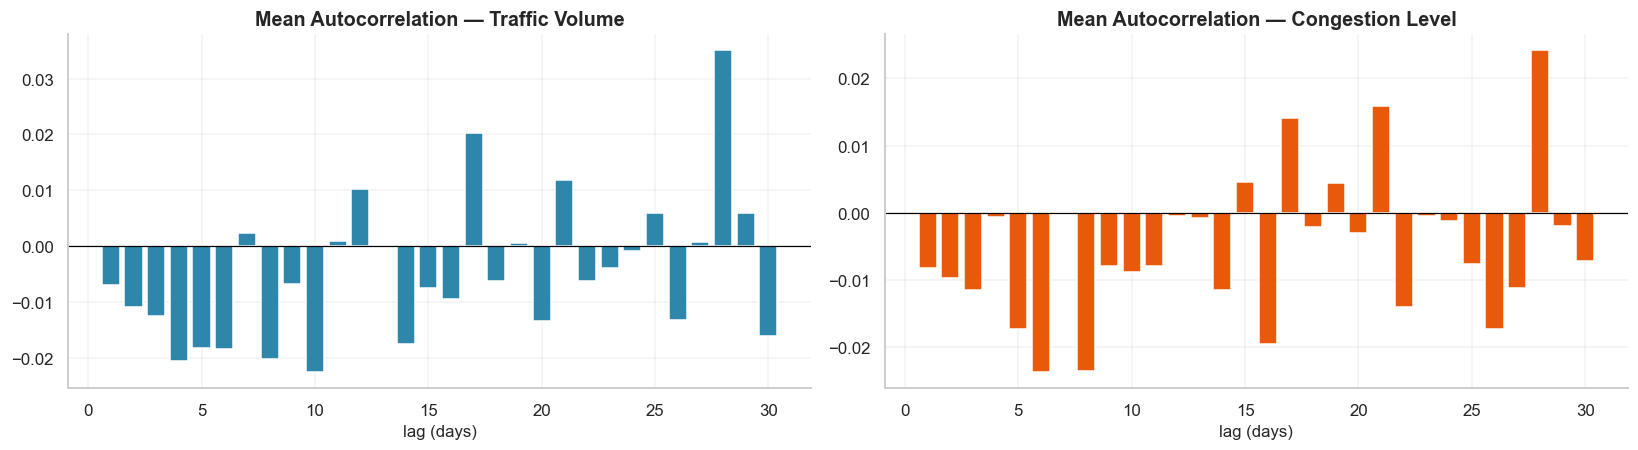

In [16]:
# ── Fig 14: Autocorrelation — how far back do lags stay useful?
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
for col, a, c in [("Traffic Volume", ax[0], PALETTE[0]),
                  ("Congestion Level", ax[1], PALETTE[2])]:
    ac = []
    for lag in range(1, 31):
        v = [g[col].autocorr(lag) for _, g in raw.sort_values("Date").groupby("intersection_id")]
        ac.append(np.nanmean(v))
    a.bar(range(1, 31), ac, color=c)
    a.axhline(0, color="black", lw=.8); a.set_title(f"Mean Autocorrelation — {col}")
    a.set_xlabel("lag (days)")
plt.tight_layout(); savefig("14_autocorrelation")

*Read-out:* autocorrelation confirms which lag depths are worth engineering. Lags 1–3, 7 and 14 are the ones this notebook builds.

---
## 3 · Feature Engineering (`features.py`)

The next cell **writes `features.py` to disk**, then imports it. Two reasons:

1. The Django backend imports the *same file* at serve time → zero train/serve skew.
2. It keeps this notebook readable while the logic stays version-controlled.

**Target convention:** every row predicts **day t+1**. Features use day ≤ t only,
except calendar fields and the weather/roadwork flags for t+1, which are genuinely
known in advance (weather = forecast, roadwork = scheduled works).

In [17]:
%%writefile features.py
"""
IntelliFlow — Shared Feature Engineering Module
================================================
SINGLE SOURCE OF TRUTH for feature computation.

Both the training notebook AND the Django serving layer import this file.
Never duplicate this logic anywhere else — that is how train/serve skew happens.

Usage (training):
    X, encoders = build_features(df, fit=True)

Usage (serving / Django):
    row = build_inference_row(history_df, target_date, area, road,
                              weather_forecast, roadwork_planned, encoders)
"""

from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --------------------------------------------------------------------------
# CONTRACT CONSTANTS — Django reads these too
# --------------------------------------------------------------------------
FEATURE_VERSION = "1.0.0"

CONGESTION_BINS = [-np.inf, 40.0, 65.0, 85.0, np.inf]
CONGESTION_LABELS = ["low", "moderate", "high", "severe"]

GREEN_TIME_MAP = {"low": 30, "moderate": 45, "high": 60, "severe": 75}
GREEN_TIME_MIN, GREEN_TIME_MAX = 20, 90

LAG_DAYS = [1, 2, 3, 7, 14]
ROLL_WINDOWS = [3, 7, 14]
WARMUP_DAYS = 14          # rows lost per intersection to lag warmup
MIN_HISTORY_DAYS = 21     # Django must supply at least this much history

RAW_COLUMNS = [
    "Date", "Area Name", "Road/Intersection Name", "Traffic Volume",
    "Average Speed", "Travel Time Index", "Congestion Level",
    "Road Capacity Utilization", "Incident Reports", "Environmental Impact",
    "Public Transport Usage", "Traffic Signal Compliance", "Parking Usage",
    "Pedestrian and Cyclist Count", "Weather Conditions",
    "Roadwork and Construction Activity",
]

# Columns that describe day t+1 and MUST NEVER be used un-lagged as features.
LEAKY_COLUMNS = [
    "Traffic Volume", "Average Speed", "Travel Time Index",
    "Congestion Level", "Road Capacity Utilization", "Environmental Impact",
]

ADVERSE_WEATHER = {"Rain", "Fog"}


# --------------------------------------------------------------------------
# Small helpers
# --------------------------------------------------------------------------
def make_intersection_id(area: str, road: str) -> str:
    """Composite key used everywhere, including Django's Intersection model."""
    return f"{str(area).strip()}::{str(road).strip()}"


def classify_congestion(level: float) -> str:
    """Map a raw 0-100 congestion score to its class label."""
    if level is None or (isinstance(level, float) and np.isnan(level)):
        return CONGESTION_LABELS[0]
    for upper, label in zip(CONGESTION_BINS[1:], CONGESTION_LABELS):
        if level < upper:
            return label
    return CONGESTION_LABELS[-1]


def recommend_green_seconds(congestion_class: str, num_approaches: int = 4) -> int:
    """Decision-support only. No physical signal hardware is driven."""
    base = GREEN_TIME_MAP.get(congestion_class, 45)
    adj = base * (1 + 0.05 * (num_approaches - 4))
    return int(np.clip(round(adj), GREEN_TIME_MIN, GREEN_TIME_MAX))


def _india_holidays(years):
    """Karnataka holiday calendar. Degrades to empty set if lib missing."""
    try:
        import holidays as _h
        return _h.India(subdiv="KA", years=list(years))
    except Exception:
        return {}


def _slope(series: pd.Series) -> float:
    """Least-squares slope of a short window — congestion momentum."""
    y = series.to_numpy(dtype=float)
    if len(y) < 2 or np.isnan(y).any():
        return 0.0
    x = np.arange(len(y), dtype=float)
    return float(np.polyfit(x, y, 1)[0])


# --------------------------------------------------------------------------
# Normalisation: raw CSV -> canonical long frame
# --------------------------------------------------------------------------
def normalize_raw(df: pd.DataFrame) -> pd.DataFrame:
    """Rename to snake_case, build intersection_id, sort, dedupe."""
    d = df.copy()
    d["Date"] = pd.to_datetime(d["Date"])
    d = d.rename(columns={
        "Date": "date",
        "Area Name": "area",
        "Road/Intersection Name": "road",
        "Traffic Volume": "volume",
        "Average Speed": "speed",
        "Travel Time Index": "tti",
        "Congestion Level": "congestion",
        "Road Capacity Utilization": "capacity_util",
        "Incident Reports": "incidents",
        "Environmental Impact": "env_impact",
        "Public Transport Usage": "pt_usage",
        "Traffic Signal Compliance": "signal_compliance",
        "Parking Usage": "parking_usage",
        "Pedestrian and Cyclist Count": "ped_count",
        "Weather Conditions": "weather",
        "Roadwork and Construction Activity": "roadwork",
    })
    d["intersection_id"] = [make_intersection_id(a, r)
                            for a, r in zip(d["area"], d["road"])]
    d["roadwork_flag"] = (d["roadwork"].astype(str).str.strip()
                          .str.lower().eq("yes").astype(int))
    d = (d.drop_duplicates(subset=["intersection_id", "date"], keep="last")
           .sort_values(["intersection_id", "date"])
           .reset_index(drop=True))
    return d


def reindex_continuous(d: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """
    Force a continuous daily index per intersection so lag features are
    genuinely 'N days ago' and not 'N rows ago'. Synthesized rows are flagged.
    """
    numeric = ["volume", "speed", "tti", "congestion", "capacity_util",
               "incidents", "env_impact", "pt_usage", "signal_compliance",
               "parking_usage", "ped_count", "roadwork_flag"]
    out = []
    synthesized = 0
    for iid, g in d.groupby("intersection_id", sort=False):
        g = g.set_index("date").sort_index()
        full = pd.date_range(g.index.min(), g.index.max(), freq="D")
        missing = len(full) - len(g)
        synthesized += missing
        g = g.reindex(full)
        g.index.name = "date"
        g["is_synthetic"] = g["volume"].isna().astype(int)
        g[numeric] = g[numeric].interpolate(method="linear", limit_direction="both")
        for c in ["area", "road", "intersection_id", "weather", "roadwork"]:
            g[c] = g[c].ffill().bfill()
        g["intersection_id"] = iid
        out.append(g.reset_index())
    res = pd.concat(out, ignore_index=True).sort_values(
        ["intersection_id", "date"]).reset_index(drop=True)
    res["roadwork_flag"] = res["roadwork_flag"].round().astype(int)
    if verbose:
        print(f"   reindex_continuous: {synthesized} synthetic rows inserted "
              f"({synthesized / max(len(res), 1):.2%} of final)")
    return res


# --------------------------------------------------------------------------
# THE feature builder
# --------------------------------------------------------------------------
def build_features(
    df: pd.DataFrame,
    encoders: dict | None = None,
    fit: bool = False,
    profile_source: pd.DataFrame | None = None,
    dropna: bool = True,
    verbose: bool = True,
) -> tuple[pd.DataFrame, dict]:
    """
    Build the model-ready frame.

    Target convention
    -----------------
    Every row describes a PREDICTION FOR DAY t+1.
      * `target_volume` / `target_congestion` / `target_class` come from day t+1
      * every feature is derived from day <= t, EXCEPT calendar features and
        weather/roadwork for t+1, which are legitimately known in advance
        (weather = forecast, roadwork = scheduled).

    Parameters
    ----------
    fit : True during training (fits encoders + intersection profiles),
          False at serve time (reuses supplied encoders).
    profile_source : frame used to compute static per-intersection profile stats.
          Pass the TRAIN SPLIT ONLY during training to avoid leakage.
    """
    d = df.copy()
    if "intersection_id" not in d.columns:
        d = normalize_raw(d)
    d = d.sort_values(["intersection_id", "date"]).reset_index(drop=True)

    if encoders is None:
        encoders = {}
    g = d.groupby("intersection_id", sort=False)

    F = pd.DataFrame(index=d.index)
    F["intersection_id"] = d["intersection_id"]
    F["date"] = d["date"]                      # date of day t (feature date)

    # ---------------- TARGETS (day t+1) ----------------
    F["target_date"] = g["date"].shift(-1)
    F["target_volume"] = g["volume"].shift(-1)
    F["target_congestion"] = g["congestion"].shift(-1)

    # ---------------- Known-in-advance context for t+1 ----------------
    nxt_weather = g["weather"].shift(-1)
    nxt_roadwork = g["roadwork_flag"].shift(-1)

    # ---------------- TEMPORAL (of target day t+1) ----------------
    td = pd.to_datetime(F["target_date"])
    F["day_of_week"] = td.dt.dayofweek
    F["day_of_month"] = td.dt.day
    F["month"] = td.dt.month
    F["quarter"] = td.dt.quarter
    F["week_of_year"] = td.dt.isocalendar().week.astype("float")
    F["is_weekend"] = (td.dt.dayofweek >= 5).astype("float")
    F["is_month_start"] = td.dt.is_month_start.astype("float")
    F["is_month_end"] = td.dt.is_month_end.astype("float")

    yrs = td.dropna().dt.year.unique()
    hol = _india_holidays(yrs)
    F["is_indian_holiday"] = td.map(
        lambda x: 1.0 if (pd.notna(x) and x.date() in hol) else 0.0)

    F["dow_sin"] = np.sin(2 * np.pi * F["day_of_week"] / 7)
    F["dow_cos"] = np.cos(2 * np.pi * F["day_of_week"] / 7)
    F["month_sin"] = np.sin(2 * np.pi * F["month"] / 12)
    F["month_cos"] = np.cos(2 * np.pi * F["month"] / 12)
    F["doy_sin"] = np.sin(2 * np.pi * td.dt.dayofyear / 365.25)
    F["doy_cos"] = np.cos(2 * np.pi * td.dt.dayofyear / 365.25)

    # ---------------- LAGS (day t is lag_1 relative to target t+1) ----------
    lag_spec = {
        "volume": [1, 2, 3, 7, 14],
        "congestion": [1, 2, 3, 7],
        "speed": [1, 3, 7],
        "tti": [1, 7],
        "capacity_util": [1, 7],
        "incidents": [1, 7],
        "env_impact": [1, 7],
    }
    for col, lags in lag_spec.items():
        for L in lags:
            F[f"{col}_lag_{L}"] = g[col].shift(L - 1)

    for col in ["pt_usage", "parking_usage", "signal_compliance"]:
        F[f"{col}_lag_1"] = g[col].shift(0)
    F["ped_count_lag_7"] = g["ped_count"].shift(6)

    # ---------------- ROLLING (windows END at day t) ----------------
    for w in ROLL_WINDOWS:
        F[f"volume_roll_mean_{w}"] = g["volume"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).mean())
        F[f"volume_roll_std_{w}"] = g["volume"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).std())
        F[f"volume_roll_max_{w}"] = g["volume"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).max())
        F[f"congestion_roll_mean_{w}"] = g["congestion"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).mean())
        F[f"congestion_roll_std_{w}"] = g["congestion"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).std())
        F[f"speed_roll_mean_{w}"] = g["speed"].transform(
            lambda s, w=w: s.rolling(w, min_periods=w).mean())

    # ---------------- DELTA / MOMENTUM ----------------
    F["volume_diff_1"] = F["volume_lag_1"] - F["volume_lag_2"]
    F["volume_diff_7"] = F["volume_lag_1"] - F["volume_lag_7"]
    F["volume_pct_change"] = F["volume_diff_1"] / (F["volume_lag_2"].abs() + 1)
    F["congestion_diff_1"] = F["congestion_lag_1"] - F["congestion_lag_2"]
    F["congestion_diff_7"] = F["congestion_lag_1"] - F["congestion_lag_7"]
    F["congestion_trend_7"] = g["congestion"].transform(
        lambda s: s.rolling(7, min_periods=7).apply(_slope, raw=False))
    F["volume_vs_roll7"] = F["volume_lag_1"] / (F["volume_roll_mean_7"] + 1)
    F["congestion_vs_roll7"] = F["congestion_lag_1"] - F["congestion_roll_mean_7"]
    F["congestion_saturated_lag_1"] = (F["congestion_lag_1"] >= 99.5).astype("float")
    F["congestion_saturated_streak_7"] = g["congestion"].transform(
        lambda s: s.ge(99.5).rolling(7, min_periods=7).sum())

    # ---------------- SPATIAL / NEIGHBOUR ----------------
    d_tmp = d[["date", "area", "intersection_id", "congestion", "volume"]].copy()
    area_daily = (d_tmp.groupby(["area", "date"], as_index=False)
                  .agg(area_cong=("congestion", "mean"),
                       area_vol=("volume", "mean"),
                       area_n=("congestion", "size")))
    d_tmp = d_tmp.merge(area_daily, on=["area", "date"], how="left")
    # leave-one-out so an intersection never sees its own same-day value
    denom = (d_tmp["area_n"] - 1).replace(0, np.nan)
    d_tmp["peer_cong"] = ((d_tmp["area_cong"] * d_tmp["area_n"]
                           - d_tmp["congestion"]) / denom)
    d_tmp["peer_cong"] = d_tmp["peer_cong"].fillna(d_tmp["area_cong"])
    F["area_peer_congestion_lag_1"] = (
        d_tmp.groupby("intersection_id")["peer_cong"].shift(0).to_numpy())
    F["area_peer_congestion_roll_7"] = (
        d_tmp.groupby("intersection_id")["peer_cong"]
        .transform(lambda s: s.rolling(7, min_periods=7).mean()).to_numpy())

    city_daily = (d_tmp.groupby("date", as_index=False)
                  .agg(city_cong=("congestion", "mean")))
    city_map = dict(zip(city_daily["date"], city_daily["city_cong"]))
    F["city_congestion_lag_1"] = d["date"].map(city_map)

    # ---------------- CATEGORICAL ENCODING ----------------
    def _enc(name, values, classes_hint=None):
        vals = pd.Series(values).astype(str).fillna("UNK")
        if fit:
            le = LabelEncoder()
            uniq = sorted(set(vals) | {"UNK"})
            le.fit(uniq)
            encoders[name] = le
        le = encoders.get(name)
        if le is None:
            raise KeyError(f"Encoder '{name}' missing. Train with fit=True first.")
        known = set(le.classes_)
        vals = vals.where(vals.isin(known), "UNK")
        return le.transform(vals).astype(float)

    F["area_encoded"] = _enc("area", d["area"])
    F["intersection_encoded"] = _enc("intersection", d["intersection_id"])
    F["weather_encoded"] = _enc("weather", nxt_weather.fillna("Clear"))
    F["is_adverse_weather"] = nxt_weather.isin(ADVERSE_WEATHER).astype(float)
    F["weather_encoded_lag_1"] = _enc("weather", d["weather"])
    F["roadwork_flag"] = nxt_roadwork.astype(float)
    F["roadwork_flag_lag_1"] = d["roadwork_flag"].astype(float)

    # ---------------- STATIC INTERSECTION PROFILE ----------------
    src = profile_source if profile_source is not None else d
    if fit or "intersection_profile" not in encoders:
        prof = (src.groupby("intersection_id")
                .agg(hist_mean_volume=("volume", "mean"),
                     hist_std_volume=("volume", "std"),
                     hist_mean_congestion=("congestion", "mean"),
                     hist_mean_speed=("speed", "mean"),
                     hist_severe_rate=("congestion", lambda s: (s >= 85).mean()))
                .fillna(0.0))
        encoders["intersection_profile"] = prof
    prof = encoders["intersection_profile"]
    glob = prof.mean(numeric_only=True)
    for c in prof.columns:
        F[f"prof_{c}"] = d["intersection_id"].map(prof[c]).fillna(glob[c]).astype(float)
    F["volume_vs_profile"] = F["volume_lag_1"] / (F["prof_hist_mean_volume"] + 1)

    # ---------------- FINALISE ----------------
    F["target_class"] = F["target_congestion"].map(
        lambda v: classify_congestion(v) if pd.notna(v) else np.nan)

    meta_cols = ["intersection_id", "date", "target_date",
                 "target_volume", "target_congestion", "target_class"]
    feat_cols = [c for c in F.columns if c not in meta_cols]

    if dropna:
        before = len(F)
        F = F.dropna(subset=feat_cols + ["target_volume", "target_class"]).reset_index(drop=True)
        if verbose:
            print(f"   build_features: {before} -> {len(F)} rows "
                  f"({before - len(F)} dropped to lag warmup / final row)")

    F[feat_cols] = F[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    encoders["feature_columns"] = feat_cols
    encoders["feature_version"] = FEATURE_VERSION

    assert_no_leakage(feat_cols, verbose=verbose)
    return F, encoders


def assert_no_leakage(feature_cols, verbose: bool = True) -> None:
    """Fail loudly if any same-day target measurement slipped into X."""
    banned_exact = {"volume", "congestion", "speed", "tti", "capacity_util",
                    "env_impact", "target_volume", "target_congestion",
                    "target_class", "Congestion Level", "Traffic Volume"}
    bad = [c for c in feature_cols if c in banned_exact]
    if bad:
        raise AssertionError(f"LEAKAGE: same-day target columns in X -> {bad}")
    if verbose:
        print("   ✅ LEAKAGE CHECK PASSED — all signal columns are lagged or "
              "known-in-advance")


# --------------------------------------------------------------------------
# SERVING PATH — what Django calls
# --------------------------------------------------------------------------
def build_inference_row(
    history_df: pd.DataFrame,
    target_date,
    area: str,
    road: str,
    weather_forecast: str,
    roadwork_planned: bool,
    encoders: dict,
    peer_history: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Produce EXACTLY ONE model-ready feature row for `target_date`.

    history_df : raw-schema rows for this intersection, ascending by date,
                 at least MIN_HISTORY_DAYS long, ending the day BEFORE target_date.
    peer_history : optional raw rows for other intersections (same schema), used
                 for the area/city neighbour features. Falls back gracefully.
    Returns a 1-row DataFrame whose columns match encoders["feature_columns"]
    in exact order.
    """
    target_date = pd.to_datetime(target_date)
    hist = normalize_raw(history_df) if "intersection_id" not in history_df.columns \
        else history_df.copy()
    hist["date"] = pd.to_datetime(hist["date"])
    iid = make_intersection_id(area, road)
    hist = hist[hist["intersection_id"] == iid].sort_values("date")

    if len(hist) < MIN_HISTORY_DAYS:
        raise ValueError(
            f"Need >= {MIN_HISTORY_DAYS} days of history for {iid}, got {len(hist)}")

    # Append a placeholder row for target_date carrying only known-in-advance info.
    stub = hist.iloc[[-1]].copy()
    stub["date"] = target_date
    stub["weather"] = weather_forecast
    stub["roadwork"] = "Yes" if roadwork_planned else "No"
    stub["roadwork_flag"] = int(bool(roadwork_planned))
    for c in ["volume", "speed", "tti", "congestion", "capacity_util",
              "incidents", "env_impact", "pt_usage", "signal_compliance",
              "parking_usage", "ped_count"]:
        stub[c] = np.nan
    frame = pd.concat([hist, stub], ignore_index=True)

    if peer_history is not None and len(peer_history):
        peers = normalize_raw(peer_history) if "intersection_id" not in peer_history.columns \
            else peer_history.copy()
        peers["date"] = pd.to_datetime(peers["date"])
        peers = peers[peers["intersection_id"] != iid]
        frame = pd.concat([frame, peers], ignore_index=True)

    F, _ = build_features(frame, encoders=encoders, fit=False,
                          dropna=False, verbose=False)
    F = F[(F["intersection_id"] == iid) & (F["target_date"] == target_date)]
    if F.empty:
        raise ValueError(f"Could not build a row for {iid} @ {target_date.date()}")

    cols = encoders["feature_columns"]
    row = F.iloc[[-1]][cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return row.reset_index(drop=True)

Writing features.py


In [18]:
import importlib, features as fx
importlib.reload(fx)

print(f"features.py loaded — FEATURE_VERSION {fx.FEATURE_VERSION}")
print("Classes:", fx.CONGESTION_LABELS, "bins:", fx.CONGESTION_BINS)

features.py loaded — FEATURE_VERSION 1.0.0
Classes: ['low', 'moderate', 'high', 'severe'] bins: [-inf, 40.0, 65.0, 85.0, inf]


In [19]:
t0 = time.time()
clean = fx.normalize_raw(raw[fx.RAW_COLUMNS])
clean = fx.reindex_continuous(clean)
F, encoders = fx.build_features(clean, fit=True)
FEATURE_COLUMNS = encoders["feature_columns"]

print(f"\nFeature matrix : {F.shape[0]:,} rows x {len(FEATURE_COLUMNS)} features")
print(f"Build time     : {time.time()-t0:.1f}s")
print(f"Target window  : {F['target_date'].min().date()} -> {F['target_date'].max().date()}")

groups = {}
for c in FEATURE_COLUMNS:
    k = ("lag" if "_lag_" in c else "rolling" if "_roll_" in c else
         "delta/momentum" if any(s in c for s in ["diff", "pct_change", "trend", "_vs_"]) else
         "profile" if c.startswith("prof_") else
         "spatial" if any(s in c for s in ["area_", "city_", "intersection_enc"]) else
         "temporal" if any(s in c for s in ["day", "month", "week", "quarter", "sin", "cos", "holiday", "weekend"]) else
         "context")
    groups.setdefault(k, []).append(c)
print("\nFeature groups:")
for k, v in sorted(groups.items(), key=lambda x: -len(x[1])):
    print(f"  {k:16s} {len(v):3d}   e.g. {', '.join(v[:3])}")

   reindex_continuous: 6271 synthetic rows inserted (41.24% of final)
   build_features: 15207 -> 14983 rows (224 dropped to lag warmup / final row)
   ✅ LEAKAGE CHECK PASSED — all signal columns are lagged or known-in-advance

Feature matrix : 14,983 rows x 83 features
Build time     : 0.7s
Target window  : 2022-01-15 -> 2024-08-09

Feature groups:
  lag               29   e.g. volume_lag_1, volume_lag_2, volume_lag_3
  rolling           19   e.g. volume_roll_mean_3, volume_roll_std_3, volume_roll_max_3
  temporal          15   e.g. day_of_week, day_of_month, month
  delta/momentum     9   e.g. volume_diff_1, volume_diff_7, volume_pct_change
  profile            5   e.g. prof_hist_mean_volume, prof_hist_std_volume, prof_hist_mean_congestion
  context            4   e.g. congestion_saturated_streak_7, weather_encoded, is_adverse_weather
  spatial            2   e.g. area_encoded, intersection_encoded


---
## 4 · Time-Based Split

**Never** `train_test_split(shuffle=True)` on a time series — it lets the model see the
future and inflates every score. We cut strictly by date.

In [20]:
F = F.sort_values(["target_date", "intersection_id"]).reset_index(drop=True)
dates = np.sort(F["target_date"].unique())
cut1 = dates[int(TRAIN_FRAC * len(dates))]
cut2 = dates[int((TRAIN_FRAC + VAL_FRAC) * len(dates))]

train = F[F.target_date <  cut1].reset_index(drop=True)
val   = F[(F.target_date >= cut1) & (F.target_date < cut2)].reset_index(drop=True)
test  = F[F.target_date >= cut2].reset_index(drop=True)

split_info = {
    "train": {"rows": len(train), "from": str(train.target_date.min().date()), "to": str(train.target_date.max().date())},
    "val":   {"rows": len(val),   "from": str(val.target_date.min().date()),   "to": str(val.target_date.max().date())},
    "test":  {"rows": len(test),  "from": str(test.target_date.min().date()),  "to": str(test.target_date.max().date())},
}
print(pd.DataFrame(split_info).T.to_string())
print("\n⚠ The TEST window is scored once, at the end. Model choice uses VAL only.")

        rows        from          to
train  10480  2022-01-15  2023-11-01
val     2256  2023-11-02  2024-03-21
test    2247  2024-03-22  2024-08-09

⚠ The TEST window is scored once, at the end. Model choice uses VAL only.


In [21]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

X_tr, X_va, X_te = train[FEATURE_COLUMNS], val[FEATURE_COLUMNS], test[FEATURE_COLUMNS]

# Regression target
yreg_tr, yreg_va, yreg_te = train.target_volume.values, val.target_volume.values, test.target_volume.values

# Classification target
cls_le = LabelEncoder().fit(fx.CONGESTION_LABELS)
ycls_tr = cls_le.transform(train.target_class)
ycls_va = cls_le.transform(val.target_class)
ycls_te = cls_le.transform(test.target_class)
PRESENT = np.unique(np.concatenate([ycls_tr, ycls_va, ycls_te]))
PRESENT_LABELS = cls_le.inverse_transform(PRESENT)

# Scaler fitted on TRAIN ONLY
scaler = StandardScaler().fit(X_tr)
Xs_tr, Xs_va, Xs_te = (scaler.transform(x) for x in (X_tr, X_va, X_te))

print("Scaled matrices:", Xs_tr.shape, Xs_va.shape, Xs_te.shape)
print("Classes present:", list(PRESENT_LABELS))
print("\nTrain class counts:")
print(pd.Series(cls_le.inverse_transform(ycls_tr)).value_counts().to_string())

Scaled matrices: (10480, 83) (2256, 83) (2247, 83)
Classes present: [np.str_('high'), np.str_('low'), np.str_('moderate'), np.str_('severe')]

Train class counts:
severe      4842
high        2383
moderate    2374
low          881


---
## 5 · Task A — Regression Benchmark (next-day Traffic Volume)

Every practical regressor, same features, same split. Scored on **validation**;
the test window stays sealed until Section 8.

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, HistGradientBoostingRegressor,
                              AdaBoostRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mape(y, p):
    y = np.asarray(y, float); p = np.asarray(p, float)
    m = np.abs(y) > 1e-6
    return float(np.mean(np.abs((y[m]-p[m])/y[m])) * 100)

def reg_metrics(y, p):
    rmse = float(np.sqrt(mean_squared_error(y, p)))
    mp = mape(y, p)
    return {"MAE": float(mean_absolute_error(y, p)), "RMSE": rmse,
            "MAPE": mp, "R2": float(r2_score(y, p)),
            "Acc(100-MAPE)": max(0.0, 100 - mp)}

# needs_scaling -> model is fed the standardised matrix
REGRESSORS = {
    "LinearRegression":   (LinearRegression(), True),
    "Ridge":              (Ridge(alpha=1.0, random_state=RANDOM_STATE), True),
    "Lasso":              (Lasso(alpha=0.01, max_iter=5000, random_state=RANDOM_STATE), True),
    "ElasticNet":         (ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE), True),
    "HuberRegressor":     (HuberRegressor(max_iter=800), True),
    "KNN":                (KNeighborsRegressor(n_neighbors=15, weights="distance", n_jobs=-1), True),
    "DecisionTree":       (DecisionTreeRegressor(max_depth=14, min_samples_leaf=8, random_state=RANDOM_STATE), False),
    "RandomForest":       (RandomForestRegressor(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE), False),
    "ExtraTrees":         (ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE), False),
    "GradientBoosting":   (GradientBoostingRegressor(n_estimators=300, learning_rate=0.06, max_depth=4, random_state=RANDOM_STATE), False),
    "HistGradientBoost":  (HistGradientBoostingRegressor(max_iter=400, learning_rate=0.07, random_state=RANDOM_STATE), False),
    "AdaBoost":           (AdaBoostRegressor(n_estimators=250, learning_rate=0.06, random_state=RANDOM_STATE), False),
}
if RUN_SVM:
    REGRESSORS["SVR (RBF)"] = (SVR(C=10, epsilon=0.1, kernel="rbf"), True)
if RUN_MLP:
    REGRESSORS["MLP"] = (MLPRegressor(hidden_layer_sizes=(256, 128, 64), max_iter=400,
                                      early_stopping=True, random_state=RANDOM_STATE), True)
if HAS["xgboost"]:
    REGRESSORS["XGBoost"] = (XGBRegressor(n_estimators=700, max_depth=7, learning_rate=0.05,
                                          subsample=0.85, colsample_bytree=0.8, reg_lambda=1.5,
                                          min_child_weight=3, tree_method="hist",
                                          n_jobs=-1, random_state=RANDOM_STATE), False)
if HAS["lightgbm"]:
    REGRESSORS["LightGBM"] = (LGBMRegressor(n_estimators=800, learning_rate=0.05, num_leaves=63,
                                            subsample=0.85, colsample_bytree=0.8, verbose=-1,
                                            n_jobs=-1, random_state=RANDOM_STATE), False)
if HAS["catboost"]:
    REGRESSORS["CatBoost"] = (CatBoostRegressor(iterations=700, depth=7, learning_rate=0.06,
                                                verbose=0, random_seed=RANDOM_STATE), False)

print(f"{len(REGRESSORS)} regressors queued:\n  " + "\n  ".join(REGRESSORS))

16 regressors queued:
  LinearRegression
  Ridge
  Lasso
  ElasticNet
  HuberRegressor
  KNN
  DecisionTree
  RandomForest
  ExtraTrees
  GradientBoosting
  HistGradientBoost
  AdaBoost
  SVR (RBF)
  MLP
  XGBoost
  LightGBM


In [23]:
reg_results, reg_fitted, reg_preds = [], {}, {}

for name, (model, needs_scale) in REGRESSORS.items():
    Xa, Xb = (Xs_tr, Xs_va) if needs_scale else (X_tr, X_va)
    try:
        t0 = time.time(); model.fit(Xa, yreg_tr); fit_s = time.time() - t0
        t0 = time.time(); pv = model.predict(Xb); pred_s = time.time() - t0
        m = reg_metrics(yreg_va, pv)
        m.update({"Model": name, "FitTime_s": round(fit_s, 2),
                  "PredTime_ms": round(pred_s*1000, 1), "Scaled": needs_scale})
        reg_results.append(m); reg_fitted[name] = model; reg_preds[name] = pv
        print(f"  {name:20s} MAE {m['MAE']:9,.0f} | RMSE {m['RMSE']:9,.0f} | "
              f"MAPE {m['MAPE']:6.2f}% | R2 {m['R2']:6.3f} | {fit_s:6.1f}s")
    except Exception as e:
        print(f"  {name:20s} FAILED -> {type(e).__name__}: {e}")

reg_df = (pd.DataFrame(reg_results)
          .set_index("Model")[["MAE","RMSE","MAPE","R2","Acc(100-MAPE)","FitTime_s","PredTime_ms","Scaled"]]
          .sort_values("MAE"))
print("\n" + "="*92); print("TASK A — REGRESSION LEADERBOARD (validation)"); print("="*92)
print(reg_df.round(3).to_string())

  LinearRegression     MAE     6,072 | RMSE     8,387 | MAPE  27.10% | R2  0.502 |    0.0s
  Ridge                MAE     6,072 | RMSE     8,387 | MAPE  27.10% | R2  0.502 |    0.0s
  Lasso                MAE     6,072 | RMSE     8,387 | MAPE  27.10% | R2  0.502 |    0.5s
  ElasticNet           MAE     6,081 | RMSE     8,389 | MAPE  27.21% | R2  0.502 |    0.5s
  HuberRegressor       MAE     5,975 | RMSE     8,449 | MAPE  26.54% | R2  0.495 |    0.3s
  KNN                  MAE     6,298 | RMSE     8,627 | MAPE  28.01% | R2  0.473 |    0.0s
  DecisionTree         MAE     6,426 | RMSE     9,463 | MAPE  26.99% | R2  0.366 |    0.4s
  RandomForest         MAE     5,317 | RMSE     7,916 | MAPE  22.88% | R2  0.556 |   17.5s
  ExtraTrees           MAE     5,397 | RMSE     7,976 | MAPE  23.35% | R2  0.550 |    4.5s
  GradientBoosting     MAE     5,481 | RMSE     7,977 | MAPE  24.05% | R2  0.550 |   45.0s
  HistGradientBoost    MAE     5,451 | RMSE     7,924 | MAPE  23.97% | R2  0.556 |    0.6s

---
## 6 · Task B — Classification Benchmark (next-day Congestion Class)

In [24]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef,
                             confusion_matrix, classification_report, roc_auc_score)

def cls_metrics(y, p, proba=None):
    d = {"Accuracy": accuracy_score(y, p) * 100,
         "BalancedAcc": balanced_accuracy_score(y, p) * 100,
         "MacroF1": f1_score(y, p, average="macro", zero_division=0),
         "WeightedF1": f1_score(y, p, average="weighted", zero_division=0),
         "MacroPrec": precision_score(y, p, average="macro", zero_division=0),
         "MacroRec": recall_score(y, p, average="macro", zero_division=0),
         "Kappa": cohen_kappa_score(y, p), "MCC": matthews_corrcoef(y, p)}
    if proba is not None:
        try:
            d["ROC_AUC_ovr"] = roc_auc_score(y, proba, multi_class="ovr",
                                             average="macro", labels=PRESENT)
        except Exception:
            d["ROC_AUC_ovr"] = np.nan
    return {k: float(v) for k, v in d.items()}

CLASSIFIERS = {
    "LogisticRegression": (LogisticRegression(max_iter=2000, class_weight="balanced",
                                              multi_class="multinomial", n_jobs=-1,
                                              random_state=RANDOM_STATE), True),
    "SGDClassifier":      (SGDClassifier(loss="log_loss", class_weight="balanced",
                                         max_iter=2000, random_state=RANDOM_STATE), True),
    "LDA":                (LinearDiscriminantAnalysis(), True),
    "GaussianNB":         (GaussianNB(), True),
    "KNN":                (KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1), True),
    "DecisionTree":       (DecisionTreeClassifier(max_depth=14, min_samples_leaf=8,
                                                  class_weight="balanced", random_state=RANDOM_STATE), False),
    "RandomForest":       (RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                                                  class_weight="balanced", n_jobs=-1,
                                                  random_state=RANDOM_STATE), False),
    "ExtraTrees":         (ExtraTreesClassifier(n_estimators=500, min_samples_leaf=2,
                                                class_weight="balanced", n_jobs=-1,
                                                random_state=RANDOM_STATE), False),
    "GradientBoosting":   (GradientBoostingClassifier(n_estimators=250, learning_rate=0.06,
                                                      max_depth=4, random_state=RANDOM_STATE), False),
    "HistGradientBoost":  (HistGradientBoostingClassifier(max_iter=400, learning_rate=0.07,
                                                          class_weight="balanced",
                                                          random_state=RANDOM_STATE), False),
    "AdaBoost":           (AdaBoostClassifier(n_estimators=250, learning_rate=0.06,
                                              random_state=RANDOM_STATE), False),
}
if RUN_SVM:
    CLASSIFIERS["SVC (RBF)"] = (SVC(C=10, kernel="rbf", probability=True,
                                    class_weight="balanced", random_state=RANDOM_STATE), True)
if RUN_MLP:
    CLASSIFIERS["MLP"] = (MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=400,
                                        early_stopping=True, random_state=RANDOM_STATE), True)
if HAS["xgboost"]:
    CLASSIFIERS["XGBoost"] = (XGBClassifier(n_estimators=700, max_depth=7, learning_rate=0.05,
                                            subsample=0.85, colsample_bytree=0.8, reg_lambda=1.5,
                                            min_child_weight=3, objective="multi:softprob",
                                            num_class=len(PRESENT), tree_method="hist",
                                            n_jobs=-1, random_state=RANDOM_STATE), False)
if HAS["lightgbm"]:
    CLASSIFIERS["LightGBM"] = (LGBMClassifier(n_estimators=800, learning_rate=0.05, num_leaves=63,
                                              subsample=0.85, colsample_bytree=0.8,
                                              class_weight="balanced", verbose=-1,
                                              n_jobs=-1, random_state=RANDOM_STATE), False)
if HAS["catboost"]:
    CLASSIFIERS["CatBoost"] = (CatBoostClassifier(iterations=700, depth=7, learning_rate=0.06,
                                                  loss_function="MultiClass", verbose=0,
                                                  random_seed=RANDOM_STATE), False)

print(f"{len(CLASSIFIERS)} classifiers queued:\n  " + "\n  ".join(CLASSIFIERS))

15 classifiers queued:
  LogisticRegression
  SGDClassifier
  LDA
  GaussianNB
  KNN
  DecisionTree
  RandomForest
  ExtraTrees
  GradientBoosting
  HistGradientBoost
  AdaBoost
  SVC (RBF)
  MLP
  XGBoost
  LightGBM


In [25]:
cls_results, cls_fitted, cls_preds = [], {}, {}

for name, (model, needs_scale) in CLASSIFIERS.items():
    Xa, Xb = (Xs_tr, Xs_va) if needs_scale else (X_tr, X_va)
    try:
        t0 = time.time(); model.fit(Xa, ycls_tr); fit_s = time.time() - t0
        t0 = time.time(); pc = model.predict(Xb); pred_s = time.time() - t0
        pc = np.asarray(pc).ravel().astype(int)
        pr = model.predict_proba(Xb) if hasattr(model, "predict_proba") else None
        m = cls_metrics(ycls_va, pc, pr)
        m.update({"Model": name, "FitTime_s": round(fit_s, 2),
                  "PredTime_ms": round(pred_s*1000, 1), "Scaled": needs_scale})
        cls_results.append(m); cls_fitted[name] = model; cls_preds[name] = pc
        print(f"  {name:20s} Acc {m['Accuracy']:6.2f}% | MacroF1 {m['MacroF1']:.4f} | "
              f"BalAcc {m['BalancedAcc']:6.2f}% | MCC {m['MCC']:+.3f} | {fit_s:6.1f}s")
    except Exception as e:
        print(f"  {name:20s} FAILED -> {type(e).__name__}: {e}")

cls_df = (pd.DataFrame(cls_results).set_index("Model")
          .sort_values(["MacroF1", "Accuracy"], ascending=False))
print("\n" + "="*112); print("TASK B — CLASSIFICATION LEADERBOARD (validation)"); print("="*112)
print(cls_df.round(4).to_string())

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

  LogisticRegression   Acc  61.08% | MacroF1 0.5581 | BalAcc  58.13% | MCC +0.436 |    1.4s
  SGDClassifier        Acc  60.33% | MacroF1 0.5311 | BalAcc  55.74% | MCC +0.418 |    0.4s
  LDA                  Acc  65.07% | MacroF1 0.5674 | BalAcc  56.26% | MCC +0.463 |    0.0s
  GaussianNB           Acc  59.57% | MacroF1 0.5325 | BalAcc  54.82% | MCC +0.405 |    0.0s
  KNN                  Acc  63.79% | MacroF1 0.5082 | BalAcc  49.50% | MCC +0.430 |    0.0s
  DecisionTree         Acc  61.48% | MacroF1 0.5690 | BalAcc  61.03% | MCC +0.454 |    0.4s
  RandomForest         Acc  74.56% | MacroF1 0.6865 | BalAcc  66.07% | MCC +0.606 |    2.7s
  ExtraTrees           Acc  71.90% | MacroF1 0.6524 | BalAcc  63.01% | MCC +0.565 |    0.8s
  GradientBoosting     Acc  73.49% | MacroF1 0.6795 | BalAcc  65.63% | MCC +0.590 |  150.8s
  HistGradientBoost    Acc  73.76% | MacroF1 0.6948 | BalAcc  69.00% | MCC +0.601 |    1.6s
  AdaBoost             Acc  64.01% | MacroF1 0.4383 | BalAcc  46.26% | MCC +0.43

---
## 7 · LSTM — Sequence Model

Fed differently from everything above: a rolling window of the last `LSTM_SEQ_LEN` days
of raw signals per intersection → next-day volume. Skipped cleanly if TensorFlow is absent.

Sequences: (14983, 14, 12)  targets: (14983,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 128)        │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,713 (483.25 KB)

 Trainable params: 123,713 (483.25 KB)

 Non-trainable params: 0 (0.00 B)

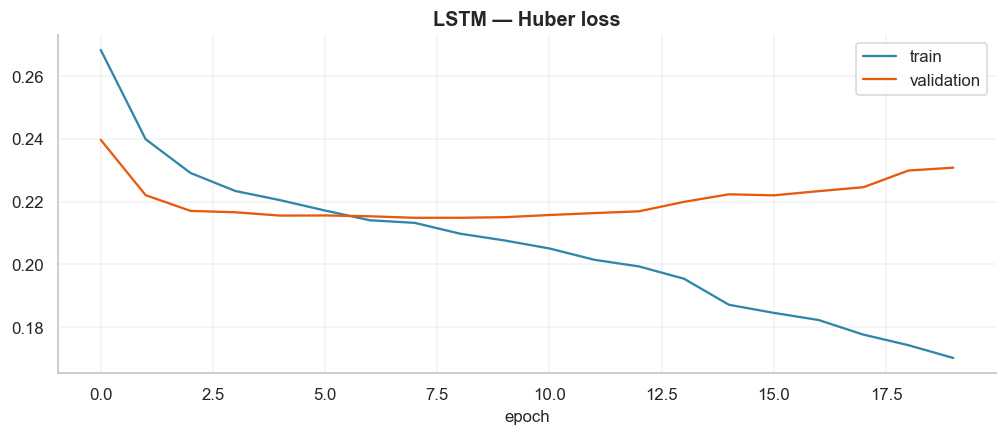


LSTM (validation): {'MAE': 6058.351, 'RMSE': 8559.201, 'MAPE': 27.153, 'R2': 0.481, 'Acc(100-MAPE)': 72.847, 'Scaled': 1}


In [26]:
lstm_reg_metrics = None; lstm_model = None; lstm_scalers = None

if RUN_LSTM and HAS["tensorflow"]:
    SEQ_COLS = ["volume", "congestion", "speed", "tti", "capacity_util",
                "incidents", "pt_usage", "parking_usage", "ped_count", "roadwork_flag"]
    base = clean.sort_values(["intersection_id", "date"]).reset_index(drop=True)
    base["dow"] = base["date"].dt.dayofweek / 6.0
    base["is_wknd"] = (base["date"].dt.dayofweek >= 5).astype(float)
    SEQ_COLS_ALL = SEQ_COLS + ["dow", "is_wknd"]

    Xs_, ys_, ds_ = [], [], []
    for iid, g in base.groupby("intersection_id"):
        arr = g[SEQ_COLS_ALL].to_numpy(float)
        vol = g["volume"].to_numpy(float)
        dts = g["date"].to_numpy()
        for i in range(LSTM_SEQ_LEN, len(g)):
            Xs_.append(arr[i-LSTM_SEQ_LEN:i]); ys_.append(vol[i]); ds_.append(dts[i])
    Xseq = np.asarray(Xs_, np.float32); yseq = np.asarray(ys_, np.float32)
    dseq = pd.to_datetime(pd.Series(ds_))
    print(f"Sequences: {Xseq.shape}  targets: {yseq.shape}")

    m_tr, m_va, m_te = dseq < cut1, (dseq >= cut1) & (dseq < cut2), dseq >= cut2
    sx = StandardScaler().fit(Xseq[m_tr].reshape(-1, Xseq.shape[-1]))
    def tf_(a): return sx.transform(a.reshape(-1, a.shape[-1])).reshape(a.shape)
    sy = StandardScaler().fit(yseq[m_tr].reshape(-1, 1))
    Xl_tr, Xl_va, Xl_te = tf_(Xseq[m_tr]), tf_(Xseq[m_va]), tf_(Xseq[m_te])
    yl_tr = sy.transform(yseq[m_tr].reshape(-1, 1)).ravel()
    yl_va = sy.transform(yseq[m_va].reshape(-1, 1)).ravel()

    lstm_model = keras.Sequential([
        layers.Input(shape=(LSTM_SEQ_LEN, Xseq.shape[-1])),
        layers.LSTM(128, return_sequences=True), layers.Dropout(0.2),
        layers.LSTM(64), layers.Dropout(0.2),
        layers.Dense(32, activation="relu"), layers.Dense(1),
    ])
    lstm_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="huber", metrics=["mae"])
    lstm_model.summary()

    hist = lstm_model.fit(
        Xl_tr, yl_tr, validation_data=(Xl_va, yl_va),
        epochs=LSTM_EPOCHS, batch_size=64, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                   keras.callbacks.ReduceLROnPlateau(patience=6, factor=0.5, min_lr=1e-5)])

    plt.figure(figsize=(11, 4))
    plt.plot(hist.history["loss"], label="train", color=PALETTE[0])
    plt.plot(hist.history["val_loss"], label="validation", color=PALETTE[2])
    plt.title("LSTM — Huber loss"); plt.xlabel("epoch"); plt.legend()
    savefig("15_lstm_training_curve")

    pv = sy.inverse_transform(lstm_model.predict(Xl_va, verbose=0)).ravel()
    lstm_reg_metrics = reg_metrics(yseq[m_va], pv)
    lstm_reg_metrics.update({"FitTime_s": None, "PredTime_ms": None, "Scaled": True})
    lstm_scalers = {"x": sx, "y": sy, "seq_cols": SEQ_COLS_ALL, "seq_len": LSTM_SEQ_LEN}
    reg_df.loc["LSTM"] = pd.Series(lstm_reg_metrics)
    reg_df = reg_df.sort_values("MAE")
    print("\nLSTM (validation):", {k: round(v, 3) for k, v in
          lstm_reg_metrics.items() if isinstance(v, (int, float))})
else:
    print("LSTM skipped (RUN_LSTM=False or TensorFlow not installed).")

---
## 8 · Comparison Visuals & Winner Selection

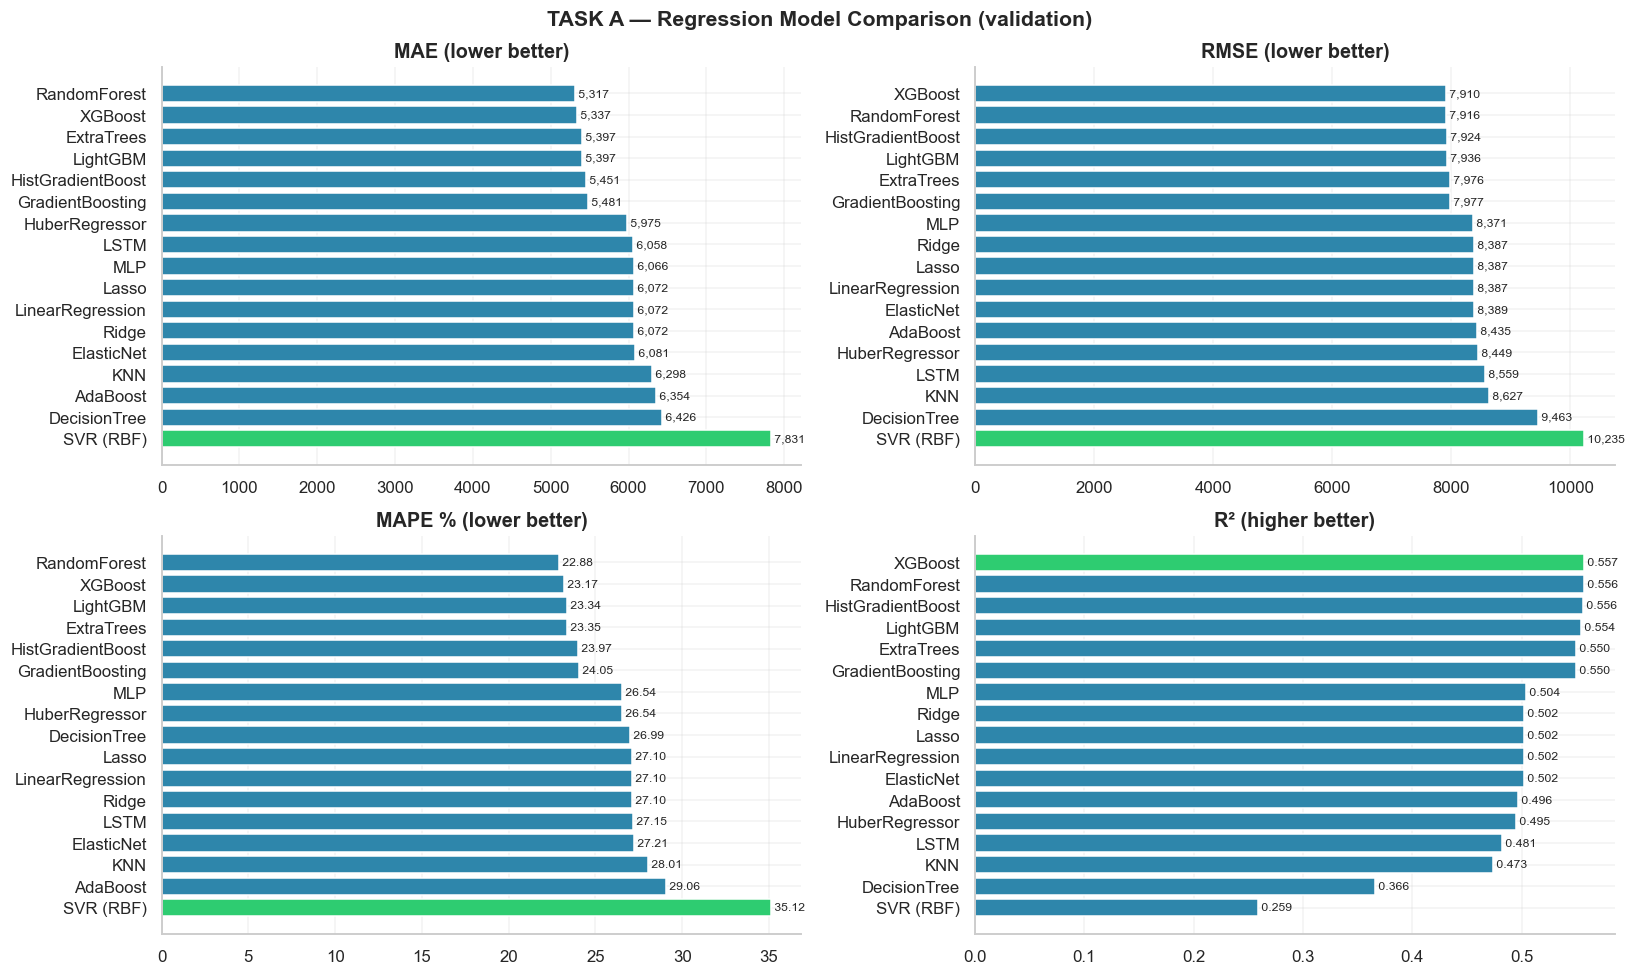

In [27]:
# ── Fig 16: Regression comparison
rd = reg_df.sort_values("MAE")
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
def hbar(a, s, title, fmt="{:.2f}", asc=True, better_low=True):
    s = s.dropna().sort_values(ascending=asc)
    cl = [PALETTE[4] if i == (len(s)-1 if asc else 0) else PALETTE[0] for i in range(len(s))]
    b = a.barh(s.index, s.values, color=cl)
    a.set_title(title)
    for bb, v in zip(b, s.values):
        a.text(v, bb.get_y()+bb.get_height()/2, " "+fmt.format(v), va="center", fontsize=8)
hbar(ax[0,0], rd["MAE"],  "MAE (lower better)",  "{:,.0f}", asc=False)
hbar(ax[0,1], rd["RMSE"], "RMSE (lower better)", "{:,.0f}", asc=False)
hbar(ax[1,0], rd["MAPE"], "MAPE % (lower better)", "{:.2f}", asc=False)
hbar(ax[1,1], rd["R2"],   "R² (higher better)",  "{:.3f}", asc=True)
fig.suptitle("TASK A — Regression Model Comparison (validation)", fontweight="bold", fontsize=14)
plt.tight_layout(); savefig("16_regression_comparison")

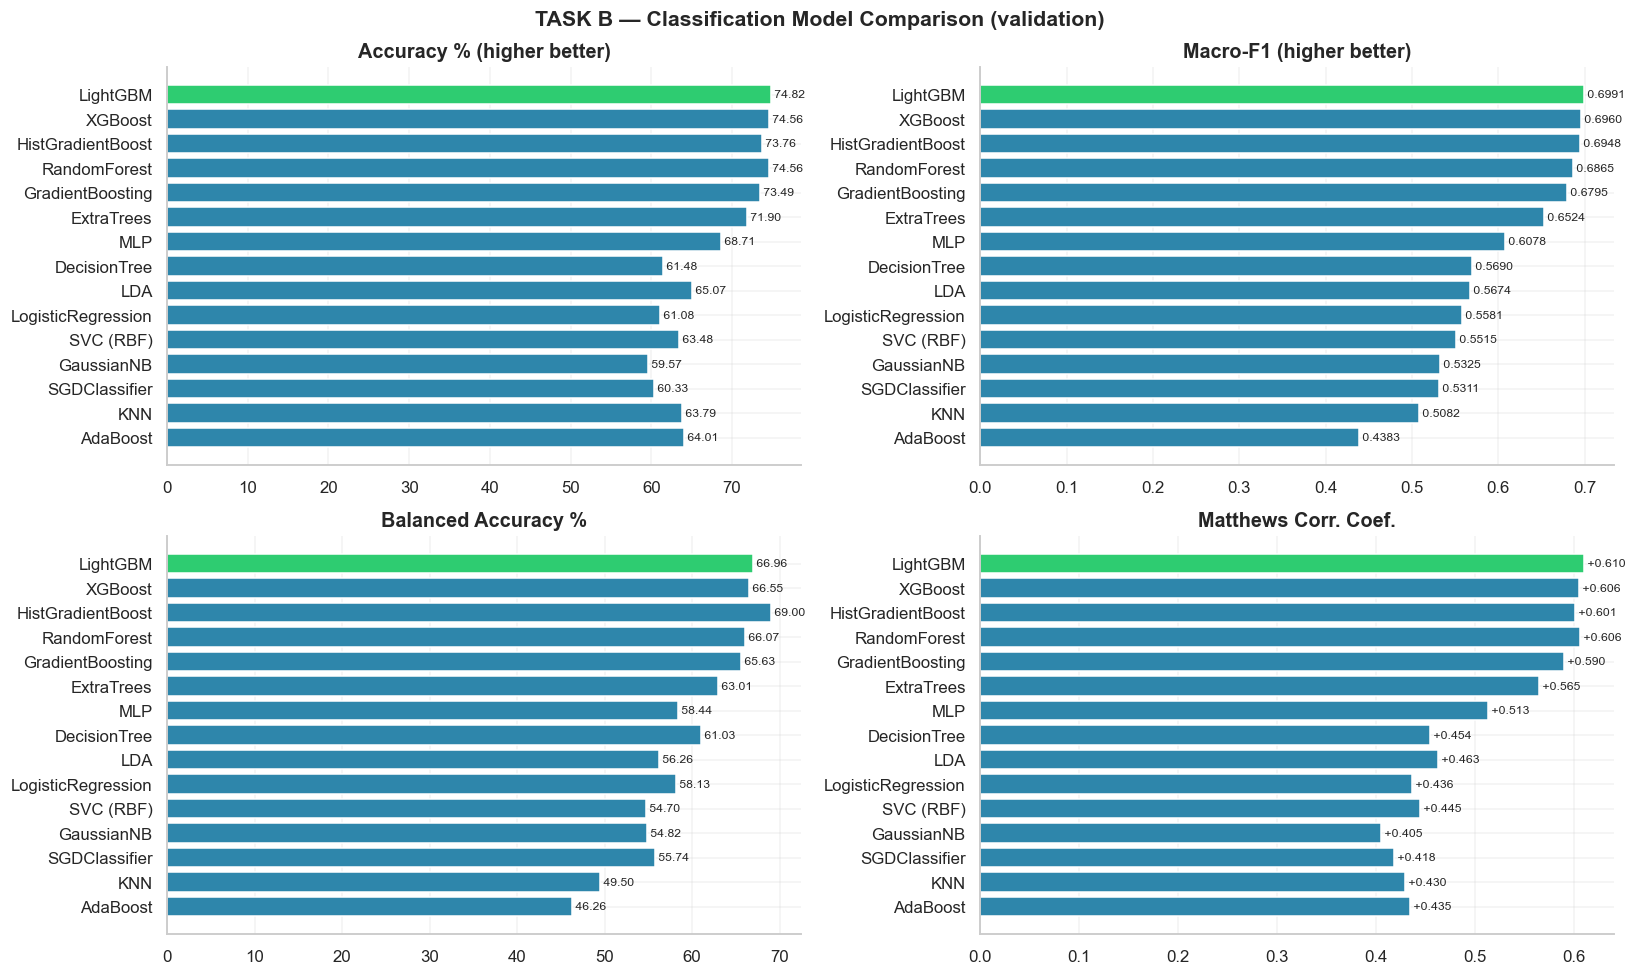

In [28]:
# ── Fig 17: Classification comparison
cd = cls_df.sort_values("MacroF1")
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
for a, col, title, fmt in [(ax[0,0], "Accuracy", "Accuracy % (higher better)", "{:.2f}"),
                           (ax[0,1], "MacroF1", "Macro-F1 (higher better)", "{:.4f}"),
                           (ax[1,0], "BalancedAcc", "Balanced Accuracy %", "{:.2f}"),
                           (ax[1,1], "MCC", "Matthews Corr. Coef.", "{:+.3f}")]:
    s = cd[col].dropna()
    cl = [PALETTE[4] if i == len(s)-1 else PALETTE[0] for i in range(len(s))]
    b = a.barh(s.index, s.values, color=cl); a.set_title(title)
    for bb, v in zip(b, s.values):
        a.text(v, bb.get_y()+bb.get_height()/2, " "+fmt.format(v), va="center", fontsize=8)
fig.suptitle("TASK B — Classification Model Comparison (validation)", fontweight="bold", fontsize=14)
plt.tight_layout(); savefig("17_classification_comparison")

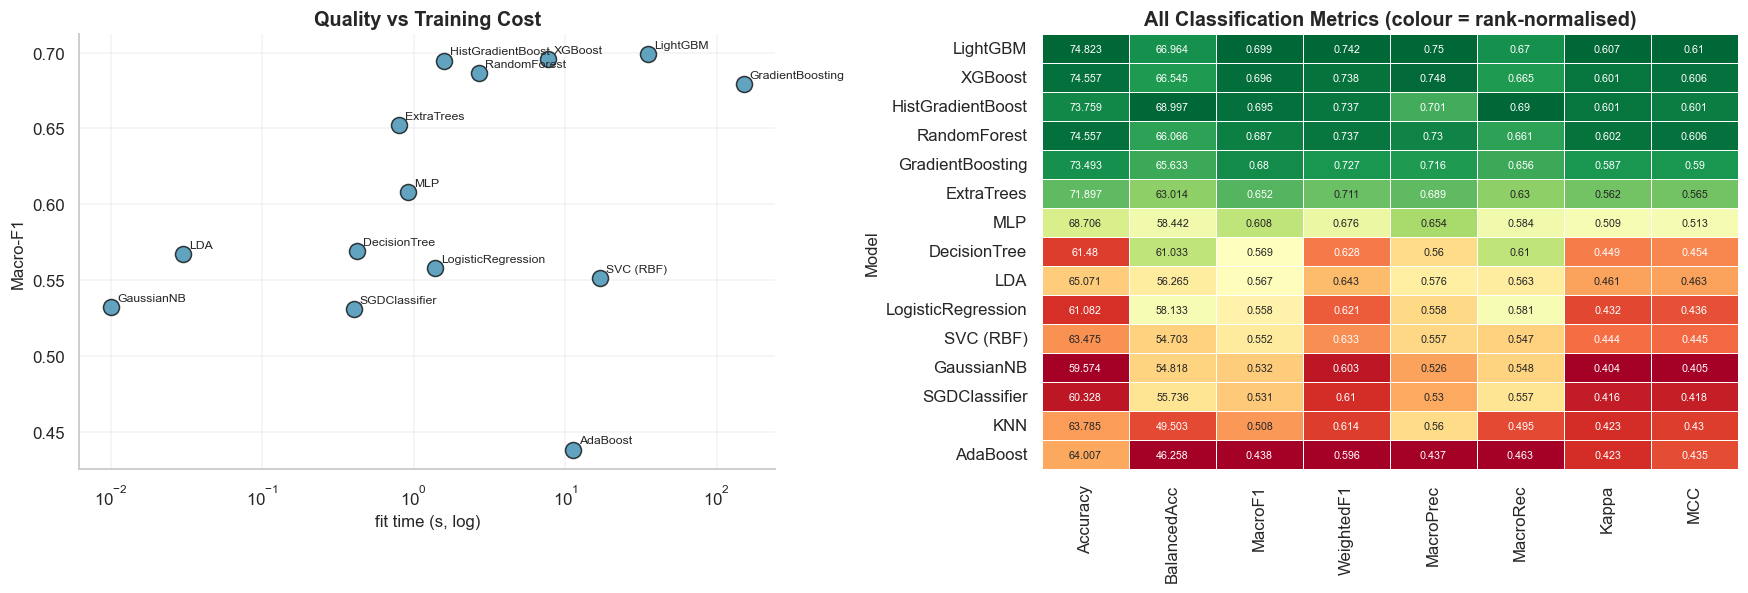

In [29]:
# ── Fig 18: Accuracy-vs-cost trade-off + normalised metric heatmap
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
sc = cls_df.dropna(subset=["FitTime_s"])
ax[0].scatter(sc["FitTime_s"], sc["MacroF1"], s=110, c=PALETTE[0], alpha=.75, edgecolor="k")
for n, r in sc.iterrows():
    ax[0].annotate(n, (r["FitTime_s"], r["MacroF1"]), fontsize=8,
                   xytext=(4, 4), textcoords="offset points")
ax[0].set_xscale("log"); ax[0].set_xlabel("fit time (s, log)"); ax[0].set_ylabel("Macro-F1")
ax[0].set_title("Quality vs Training Cost")

hm = cls_df[["Accuracy", "BalancedAcc", "MacroF1", "WeightedF1", "MacroPrec", "MacroRec", "Kappa", "MCC"]].copy()
hm_n = (hm - hm.min()) / (hm.max() - hm.min() + 1e-9)
sns.heatmap(hm_n, annot=hm.round(3), fmt="", cmap="RdYlGn", cbar=False,
            linewidths=.5, annot_kws={"size": 7}, ax=ax[1])
ax[1].set_title("All Classification Metrics (colour = rank-normalised)")
plt.tight_layout(); savefig("18_tradeoff_and_metric_heatmap")

In [30]:
# ══════════════ WINNER SELECTION (on validation only) ══════════════
BEST_REG = reg_df["MAE"].idxmin()
BEST_CLS = cls_df.sort_values(["MacroF1", "Accuracy"], ascending=False).index[0]

print("="*72)
print("WINNERS  (selected on VALIDATION — test window still sealed)")
print("="*72)
print(f"Task A · Regression     -> {BEST_REG}")
print(f"    MAE {reg_df.loc[BEST_REG,'MAE']:,.0f} | RMSE {reg_df.loc[BEST_REG,'RMSE']:,.0f} "
      f"| MAPE {reg_df.loc[BEST_REG,'MAPE']:.2f}% | R² {reg_df.loc[BEST_REG,'R2']:.3f}")
print(f"\nTask B · Classification -> {BEST_CLS}")
print(f"    Accuracy {cls_df.loc[BEST_CLS,'Accuracy']:.2f}% | Macro-F1 {cls_df.loc[BEST_CLS,'MacroF1']:.4f} "
      f"| BalAcc {cls_df.loc[BEST_CLS,'BalancedAcc']:.2f}%")
print("\nRanking rule: regression = lowest MAE; classification = highest Macro-F1,")
print("with Accuracy as tie-break (Macro-F1 first because the classes are imbalanced).")

WINNERS  (selected on VALIDATION — test window still sealed)
Task A · Regression     -> RandomForest
    MAE 5,317 | RMSE 7,916 | MAPE 22.88% | R² 0.556

Task B · Classification -> LightGBM
    Accuracy 74.82% | Macro-F1 0.6991 | BalAcc 66.96%

Ranking rule: regression = lowest MAE; classification = highest Macro-F1,
with Accuracy as tie-break (Macro-F1 first because the classes are imbalanced).


---
## 9 · Optional Tuning of the Winners

`RandomizedSearchCV` over `TimeSeriesSplit`. Set `TUNE_TOP_MODELS = False` at the top
to skip. A tuned model is only kept if it actually beats the default on validation.

In [31]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4)
GRIDS = {
    "RandomForest":      {"n_estimators":[300,500,800],"max_depth":[None,14,20,28],
                          "min_samples_leaf":[1,2,4,8],"max_features":["sqrt",0.4,0.7]},
    "ExtraTrees":        {"n_estimators":[300,500,800],"max_depth":[None,16,24],
                          "min_samples_leaf":[1,2,4],"max_features":["sqrt",0.5,0.8]},
    "XGBoost":           {"n_estimators":[400,700,1100],"max_depth":[4,6,8,10],
                          "learning_rate":[0.02,0.05,0.09],"subsample":[0.7,0.85,1.0],
                          "colsample_bytree":[0.6,0.8,1.0],"min_child_weight":[1,3,6],
                          "reg_lambda":[0.5,1.5,4.0]},
    "LightGBM":          {"n_estimators":[400,800,1200],"num_leaves":[31,63,127],
                          "learning_rate":[0.02,0.05,0.09],"subsample":[0.7,0.85,1.0],
                          "colsample_bytree":[0.6,0.8,1.0],"min_child_samples":[10,20,40]},
    "HistGradientBoost": {"max_iter":[300,500,800],"learning_rate":[0.03,0.07,0.12],
                          "max_leaf_nodes":[31,63,127],"min_samples_leaf":[10,20,40]},
}

def tune(name, base_est, X, y, scoring, needs_scale, current_score, higher_better):
    if not TUNE_TOP_MODELS or name not in GRIDS:
        print(f"  {name}: no grid / tuning disabled — keeping default."); return base_est, None
    Xa = Xs_tr if needs_scale else X_tr
    rs = RandomizedSearchCV(base_est, GRIDS[name], n_iter=TUNE_ITER, cv=tscv,
                            scoring=scoring, n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
    t0 = time.time(); rs.fit(Xa, y)
    print(f"  {name}: searched {TUNE_ITER} combos in {time.time()-t0:.0f}s")
    print(f"    best params: {rs.best_params_}")
    return rs.best_estimator_, rs.best_params_

print("── Tuning classification winner:", BEST_CLS)
cls_needs_scale = CLASSIFIERS[BEST_CLS][1] if BEST_CLS in CLASSIFIERS else False
tuned_cls, cls_params = tune(BEST_CLS, CLASSIFIERS[BEST_CLS][0], X_tr, ycls_tr,
                             "f1_macro", cls_needs_scale, cls_df.loc[BEST_CLS,"MacroF1"], True)
pc = np.asarray(tuned_cls.predict(Xs_va if cls_needs_scale else X_va)).ravel().astype(int)
tuned_f1 = f1_score(ycls_va, pc, average="macro", zero_division=0)
if tuned_f1 > cls_df.loc[BEST_CLS, "MacroF1"]:
    print(f"    ✅ tuned improves Macro-F1 {cls_df.loc[BEST_CLS,'MacroF1']:.4f} -> {tuned_f1:.4f}")
    final_cls_model = tuned_cls
else:
    print(f"    ↩ tuned did NOT improve ({tuned_f1:.4f}) — keeping default.")
    final_cls_model, cls_params = cls_fitted[BEST_CLS], None

── Tuning classification winner: LightGBM
  LightGBM: searched 20 combos in 1622s
    best params: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 400, 'min_child_samples': 40, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
    ✅ tuned improves Macro-F1 0.6991 -> 0.7046


In [32]:
print("── Tuning regression winner:", BEST_REG)
if BEST_REG == "LSTM":
    print("  Winner is the LSTM — grid search not applicable; keeping trained network.")
    final_reg_model, reg_params, reg_needs_scale = lstm_model, None, True
else:
    reg_needs_scale = REGRESSORS[BEST_REG][1]
    tuned_reg, reg_params = tune(BEST_REG, REGRESSORS[BEST_REG][0], X_tr, yreg_tr,
                                 "neg_mean_absolute_error", reg_needs_scale,
                                 reg_df.loc[BEST_REG,"MAE"], False)
    pv = tuned_reg.predict(Xs_va if reg_needs_scale else X_va)
    tuned_mae = mean_absolute_error(yreg_va, pv)
    if tuned_mae < reg_df.loc[BEST_REG, "MAE"]:
        print(f"    ✅ tuned improves MAE {reg_df.loc[BEST_REG,'MAE']:,.0f} -> {tuned_mae:,.0f}")
        final_reg_model = tuned_reg
    else:
        print(f"    ↩ tuned did NOT improve ({tuned_mae:,.0f}) — keeping default.")
        final_reg_model, reg_params = reg_fitted[BEST_REG], None

── Tuning regression winner: RandomForest
  RandomForest: searched 20 combos in 472s
    best params: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 14}
    ↩ tuned did NOT improve (5,322) — keeping default.


---
## 10 · Final Evaluation on the Sealed Test Window

First and only time the test split is scored. These are the numbers to quote.

In [33]:
# ── Classification on test
p_te = np.asarray(final_cls_model.predict(Xs_te if cls_needs_scale else X_te)).ravel().astype(int)
pr_te = (final_cls_model.predict_proba(Xs_te if cls_needs_scale else X_te)
         if hasattr(final_cls_model, "predict_proba") else None)
TEST_CLS = cls_metrics(ycls_te, p_te, pr_te)

print("="*72); print(f"FINAL TEST — Classification ({BEST_CLS})"); print("="*72)
for k, v in TEST_CLS.items():
    print(f"  {k:14s} {v:8.4f}")
print("\nPer-class report:")
print(classification_report(ycls_te, p_te, labels=PRESENT,
                            target_names=PRESENT_LABELS, zero_division=0, digits=3))

FINAL TEST — Classification (LightGBM)
  Accuracy        73.0752
  BalancedAcc     67.4736
  MacroF1          0.6858
  WeightedF1       0.7265
  MacroPrec        0.7006
  MacroRec         0.6747
  Kappa            0.5949
  MCC              0.5965
  ROC_AUC_ovr      0.8709

Per-class report:
              precision    recall  f1-score   support

        high      0.625     0.598     0.611       523
         low      0.663     0.609     0.635       207
    moderate      0.724     0.620     0.668       474
      severe      0.790     0.872     0.829      1043

    accuracy                          0.731      2247
   macro avg      0.701     0.675     0.686      2247
weighted avg      0.726     0.731     0.727      2247



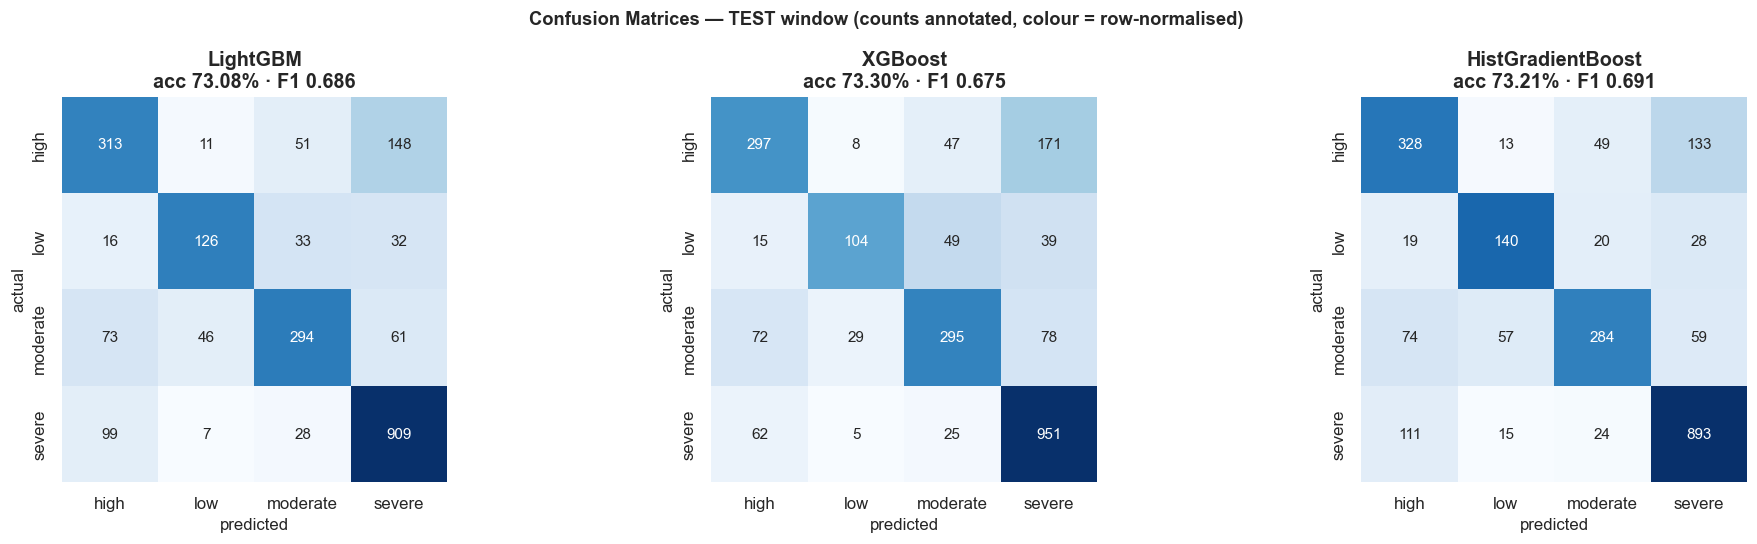

In [34]:
# ── Fig 19: Confusion matrices for the top-3 classifiers
top3 = cls_df.index[:3].tolist()
fig, axes = plt.subplots(1, len(top3), figsize=(6*len(top3), 5))
axes = np.atleast_1d(axes)
for a, name in zip(axes, top3):
    mdl = final_cls_model if name == BEST_CLS else cls_fitted[name]
    ns = CLASSIFIERS[name][1]
    pp = np.asarray(mdl.predict(Xs_te if ns else X_te)).ravel().astype(int)
    cm = confusion_matrix(ycls_te, pp, labels=PRESENT)
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues", cbar=False, square=True,
                xticklabels=PRESENT_LABELS, yticklabels=PRESENT_LABELS, ax=a)
    a.set_title(f"{name}\nacc {accuracy_score(ycls_te, pp)*100:.2f}% · "
                f"F1 {f1_score(ycls_te, pp, average='macro', zero_division=0):.3f}")
    a.set_xlabel("predicted"); a.set_ylabel("actual")
fig.suptitle("Confusion Matrices — TEST window (counts annotated, colour = row-normalised)",
             fontweight="bold")
plt.tight_layout(); savefig("19_confusion_matrices")

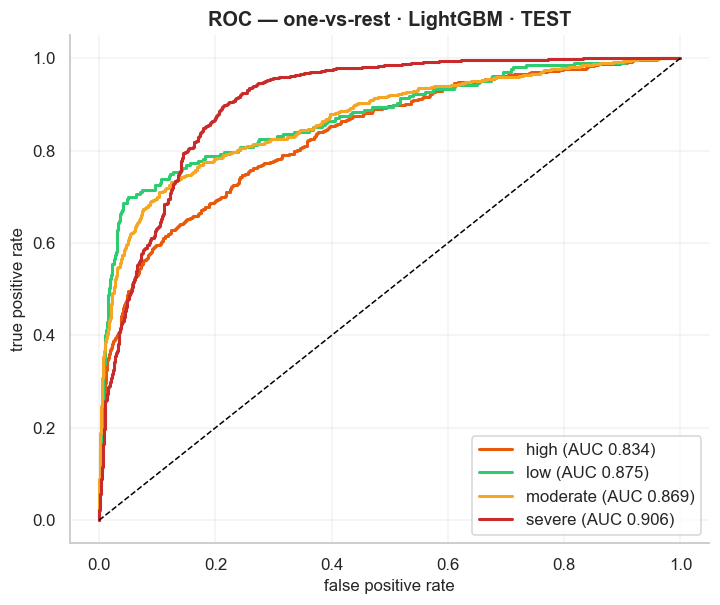

In [35]:
# ── Fig 20: One-vs-rest ROC curves for the winner
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
if pr_te is not None and len(PRESENT) > 1:
    Yb = label_binarize(ycls_te, classes=PRESENT)
    plt.figure(figsize=(7.5, 6))
    for i, lab in enumerate(PRESENT_LABELS):
        if Yb[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(Yb[:, i], pr_te[:, i])
        plt.plot(fpr, tpr, lw=2, color=CONG_COLS.get(lab, PALETTE[i % len(PALETTE)]),
                 label=f"{lab} (AUC {auc(fpr,tpr):.3f})")
    plt.plot([0,1],[0,1],"k--",lw=1)
    plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
    plt.title(f"ROC — one-vs-rest · {BEST_CLS} · TEST"); plt.legend(loc="lower right")
    savefig("20_roc_curves")

In [36]:
# ── Regression on test
if BEST_REG == "LSTM":
    pv_te = sy.inverse_transform(lstm_model.predict(Xl_te, verbose=0)).ravel()
    y_true_reg, test_dates_reg = yseq[m_te], dseq[m_te].values
else:
    pv_te = final_reg_model.predict(Xs_te if reg_needs_scale else X_te)
    y_true_reg, test_dates_reg = yreg_te, test["target_date"].values
TEST_REG = reg_metrics(y_true_reg, pv_te)

print("="*72); print(f"FINAL TEST — Regression ({BEST_REG})"); print("="*72)
for k, v in TEST_REG.items():
    print(f"  {k:16s} {v:12,.3f}")

FINAL TEST — Regression (RandomForest)
  MAE                 5,199.749
  RMSE                7,684.869
  MAPE                   23.836
  R2                      0.588
  Acc(100-MAPE)          76.164


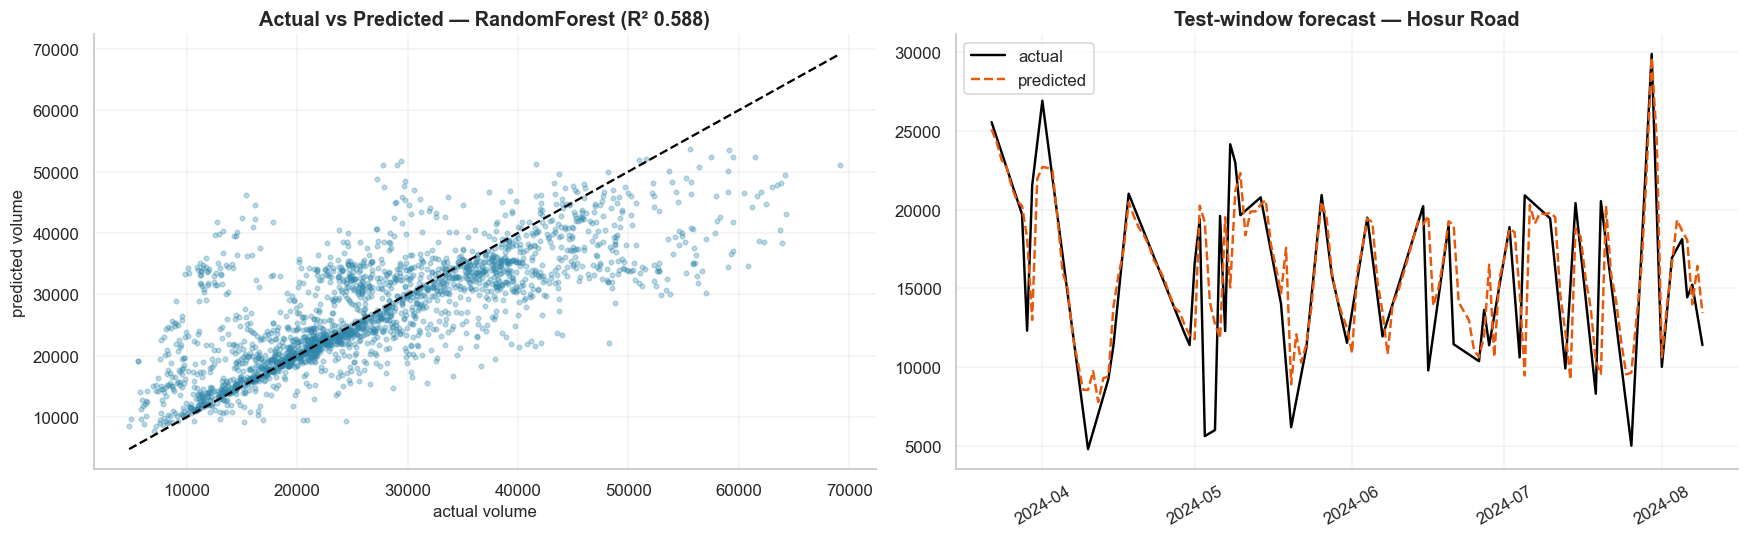

In [37]:
# ── Fig 21: Actual vs predicted
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].scatter(y_true_reg, pv_te, s=9, alpha=.3, color=PALETTE[0])
lim = [min(y_true_reg.min(), pv_te.min()), max(y_true_reg.max(), pv_te.max())]
ax[0].plot(lim, lim, "k--", lw=1.5)
ax[0].set_xlabel("actual volume"); ax[0].set_ylabel("predicted volume")
ax[0].set_title(f"Actual vs Predicted — {BEST_REG} (R² {TEST_REG['R2']:.3f})")

if BEST_REG != "LSTM":
    iid = test["intersection_id"].value_counts().idxmax()
    m = test["intersection_id"] == iid
    ax[1].plot(test.loc[m, "target_date"], yreg_te[m.values], lw=1.6,
               color="black", label="actual")
    ax[1].plot(test.loc[m, "target_date"], pv_te[m.values], lw=1.6,
               color=PALETTE[2], ls="--", label="predicted")
    ax[1].set_title(f"Test-window forecast — {iid.split('::')[-1]}")
else:
    ax[1].plot(test_dates_reg[:250], y_true_reg[:250], lw=1.4, color="black", label="actual")
    ax[1].plot(test_dates_reg[:250], pv_te[:250], lw=1.4, color=PALETTE[2], ls="--", label="predicted")
    ax[1].set_title("Test-window forecast (first 250 sequences)")
ax[1].legend(); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); savefig("21_actual_vs_predicted")

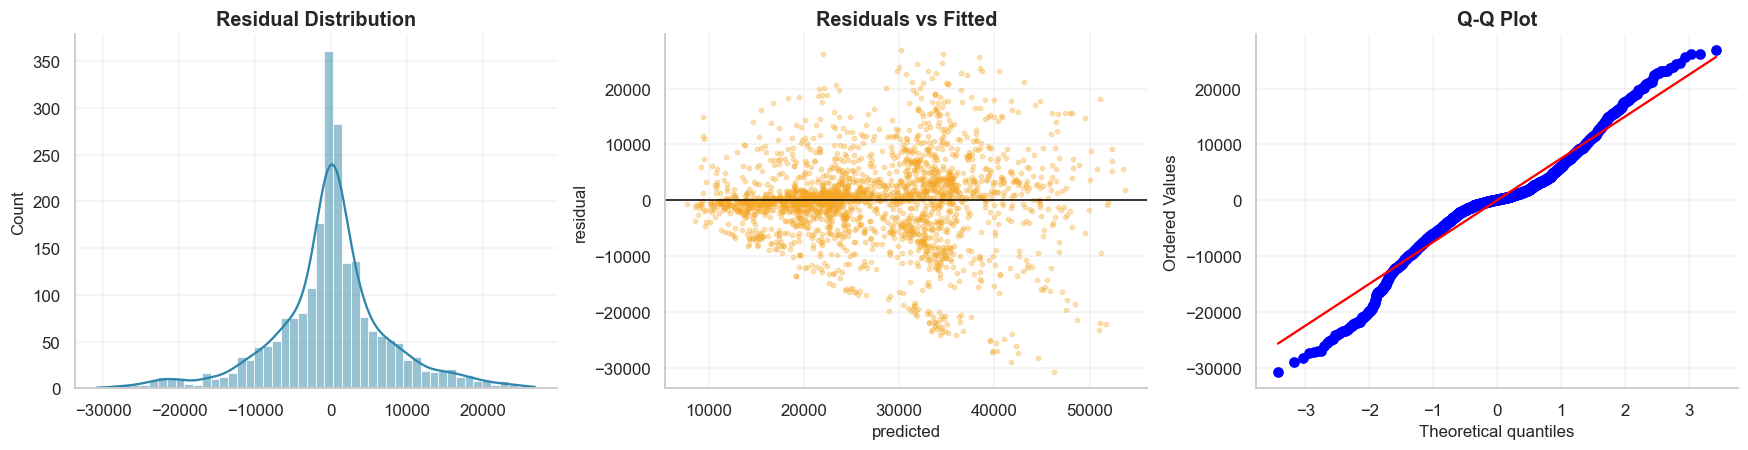

In [38]:
# ── Fig 22: Residual diagnostics
res = np.asarray(y_true_reg) - np.asarray(pv_te)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(res, bins=50, kde=True, color=PALETTE[0], ax=ax[0]); ax[0].set_title("Residual Distribution")
ax[1].scatter(pv_te, res, s=8, alpha=.3, color=PALETTE[1]); ax[1].axhline(0, color="k", lw=1)
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("residual"); ax[1].set_title("Residuals vs Fitted")
from scipy import stats as _st
_st.probplot(res, dist="norm", plot=ax[2]); ax[2].set_title("Q-Q Plot")
plt.tight_layout(); savefig("22_residual_diagnostics")

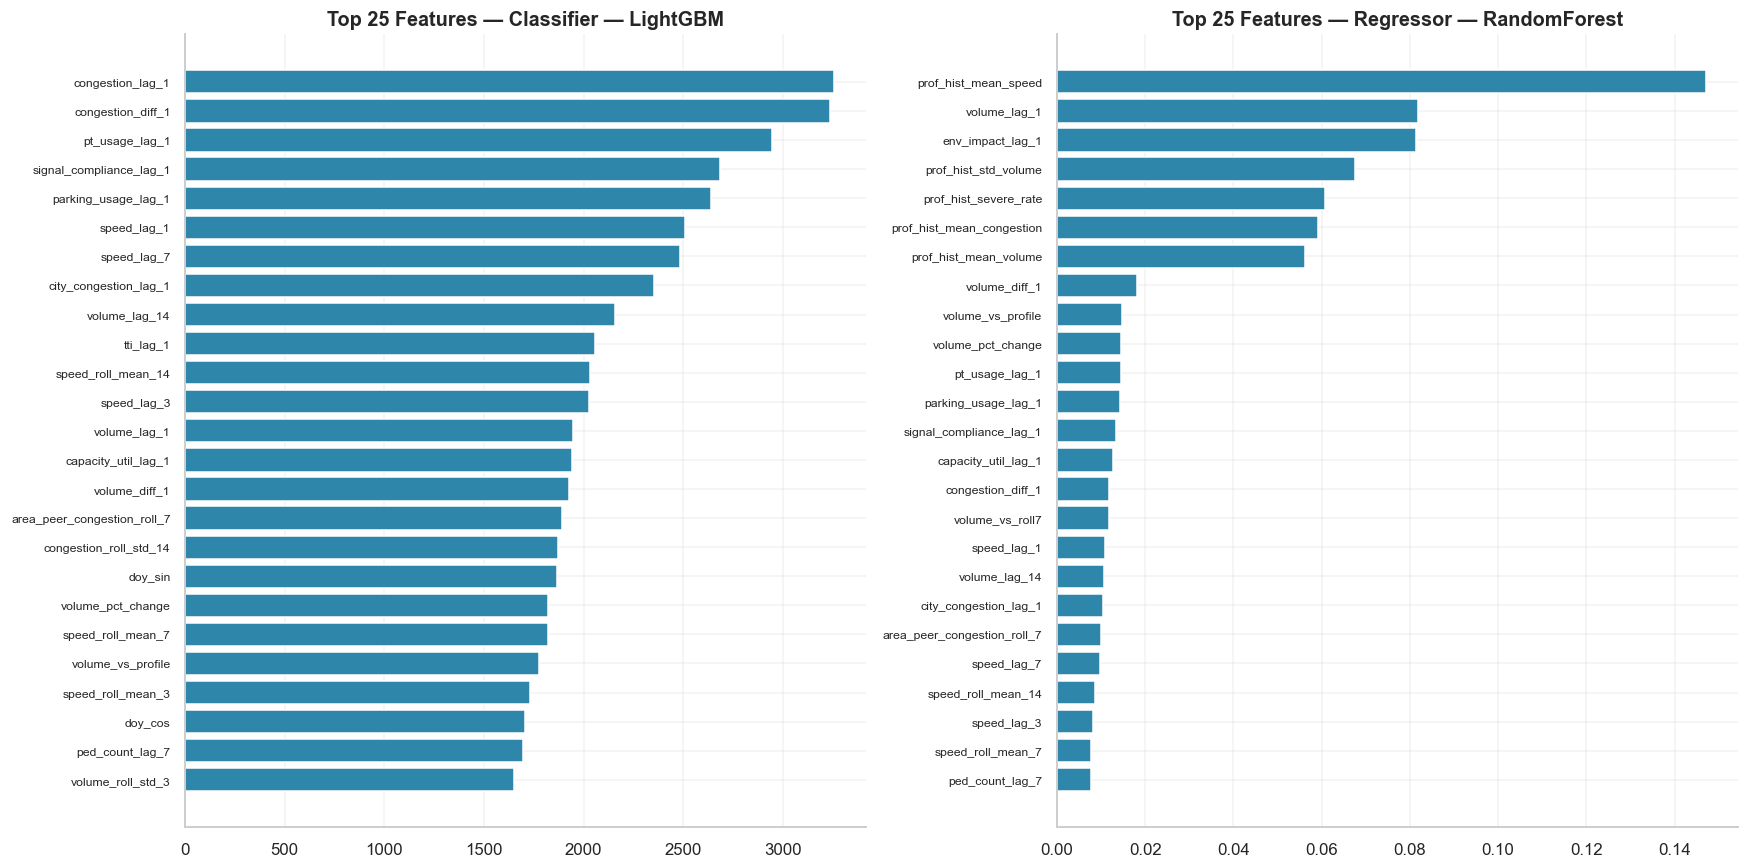

Top 15 drivers of next-day congestion class:
congestion_lag_1           3256
congestion_diff_1          3235
pt_usage_lag_1             2947
signal_compliance_lag_1    2686
parking_usage_lag_1        2640
speed_lag_1                2507
speed_lag_7                2483
city_congestion_lag_1      2353
volume_lag_14              2159
tti_lag_1                  2059
speed_roll_mean_14         2031
speed_lag_3                2028
volume_lag_1               1947
capacity_util_lag_1        1942
volume_diff_1              1925


In [39]:
# ── Fig 23: Feature importance
def importance(model, cols):
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=cols)
    if hasattr(model, "coef_"):
        c = np.asarray(model.coef_)
        return pd.Series(np.abs(c).mean(axis=0) if c.ndim > 1 else np.abs(c), index=cols)
    return None

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
for a, (mdl, ttl) in zip(ax, [(final_cls_model, f"Classifier — {BEST_CLS}"),
                              (final_reg_model, f"Regressor — {BEST_REG}")]):
    imp = importance(mdl, FEATURE_COLUMNS)
    if imp is None:
        a.text(.5, .5, "model exposes no importances", ha="center"); a.set_axis_off(); continue
    top = imp.sort_values().tail(25)
    a.barh(top.index, top.values, color=PALETTE[0]); a.set_title(f"Top 25 Features — {ttl}")
    a.tick_params(axis="y", labelsize=8)
plt.tight_layout(); savefig("23_feature_importance")

imp_c = importance(final_cls_model, FEATURE_COLUMNS)
if imp_c is not None:
    print("Top 15 drivers of next-day congestion class:")
    print(imp_c.sort_values(ascending=False).head(15).round(5).to_string())

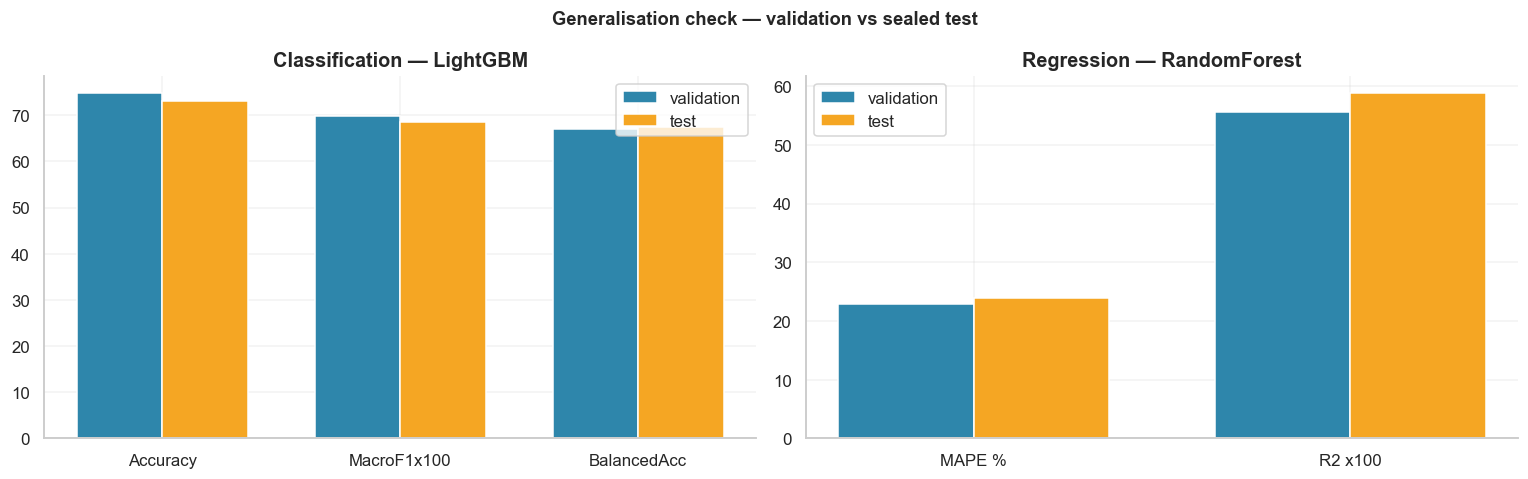

In [40]:
# ── Fig 24: Validation vs Test — overfitting check
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
c_pairs = [("Accuracy", cls_df.loc[BEST_CLS,"Accuracy"], TEST_CLS["Accuracy"]),
           ("MacroF1x100", cls_df.loc[BEST_CLS,"MacroF1"]*100, TEST_CLS["MacroF1"]*100),
           ("BalancedAcc", cls_df.loc[BEST_CLS,"BalancedAcc"], TEST_CLS["BalancedAcc"])]
x = np.arange(len(c_pairs)); w = .36
ax[0].bar(x-w/2, [p[1] for p in c_pairs], w, label="validation", color=PALETTE[0])
ax[0].bar(x+w/2, [p[2] for p in c_pairs], w, label="test", color=PALETTE[1])
ax[0].set_xticks(x); ax[0].set_xticklabels([p[0] for p in c_pairs])
ax[0].set_title(f"Classification — {BEST_CLS}"); ax[0].legend()

r_pairs = [("MAPE %", reg_df.loc[BEST_REG,"MAPE"], TEST_REG["MAPE"]),
           ("R2 x100", reg_df.loc[BEST_REG,"R2"]*100, TEST_REG["R2"]*100)]
x = np.arange(len(r_pairs))
ax[1].bar(x-w/2, [p[1] for p in r_pairs], w, label="validation", color=PALETTE[0])
ax[1].bar(x+w/2, [p[2] for p in r_pairs], w, label="test", color=PALETTE[1])
ax[1].set_xticks(x); ax[1].set_xticklabels([p[0] for p in r_pairs])
ax[1].set_title(f"Regression — {BEST_REG}"); ax[1].legend()
fig.suptitle("Generalisation check — validation vs sealed test", fontweight="bold")
plt.tight_layout(); savefig("24_val_vs_test")

---
## 11 · Save Artifacts (the Django contract)

Everything the backend needs, at fixed paths. **All** trained models are saved, not just
the winners, so the API can fall back if one fails to load.

In [41]:
BENGALURU_COORDS = {
    "Indiranagar::100 Feet Road":        (12.9719, 77.6412),
    "Indiranagar::CMH Road":             (12.9784, 77.6408),
    "Whitefield::Marathahalli Bridge":   (12.9569, 77.7011),
    "Whitefield::ITPL Main Road":        (12.9856, 77.7367),
    "Koramangala::Sony World Junction":  (12.9345, 77.6146),
    "Koramangala::Sarjapur Road":        (12.9250, 77.6270),
    "M.G. Road::Trinity Circle":         (12.9727, 77.6199),
    "M.G. Road::Anil Kumble Circle":     (12.9756, 77.6050),
    "Jayanagar::Jayanagar 4th Block":    (12.9250, 77.5838),
    "Jayanagar::South End Circle":       (12.9350, 77.5750),
    "Hebbal::Hebbal Flyover":            (13.0358, 77.5970),
    "Hebbal::Ballari Road":              (13.0450, 77.5930),
    "Yeshwanthpur::Yeshwanthpur Circle": (13.0230, 77.5500),
    "Yeshwanthpur::Tumkur Road":         (13.0280, 77.5380),
}
AREA_CENTROIDS = {}
for k, v in BENGALURU_COORDS.items():
    AREA_CENTROIDS.setdefault(k.split("::")[0], []).append(v)
AREA_CENTROIDS = {k: (float(np.mean([p[0] for p in v])), float(np.mean([p[1] for p in v])))
                  for k, v in AREA_CENTROIDS.items()}
BLR_FALLBACK = (12.9716, 77.5946)

intersections, unmapped = [], []
prof = encoders["intersection_profile"]
for iid, g in clean.groupby("intersection_id"):
    area, road = iid.split("::", 1)
    if iid in BENGALURU_COORDS:
        lat, lon = BENGALURU_COORDS[iid]; src = "curated"
    elif area in AREA_CENTROIDS:
        lat, lon = AREA_CENTROIDS[area];  src = "area_centroid"; unmapped.append(iid)
    else:
        lat, lon = BLR_FALLBACK;          src = "city_fallback"; unmapped.append(iid)
    p = prof.loc[iid] if iid in prof.index else prof.mean()
    intersections.append({
        "intersection_id": iid, "area": area, "road": road,
        "latitude": lat, "longitude": lon, "coord_source": src,
        "num_approaches": 4, "default_green_seconds": 45,
        "hist_mean_volume": float(p["hist_mean_volume"]),
        "hist_std_volume": float(p["hist_std_volume"]),
        "hist_mean_congestion": float(p["hist_mean_congestion"]),
        "hist_severe_rate": float(p["hist_severe_rate"]),
        "record_count": int(len(g)),
        "first_date": str(g["date"].min().date()), "last_date": str(g["date"].max().date()),
    })
if unmapped:
    print("⚠ No curated coordinate for these — geocode via Nominatim later:")
    for u in unmapped: print("   ", u)
print(f"\n{len(intersections)} intersections prepared for the Django map.")

⚠ No curated coordinate for these — geocode via Nominatim later:
    Electronic City::Hosur Road
    Electronic City::Silk Board Junction

16 intersections prepared for the Django map.


In [42]:
# ── Models
saved = {}
for n, m in reg_fitted.items():
    f = ART/"models"/f"reg_{n.replace(' ','_').replace('(','').replace(')','')}.pkl"
    joblib.dump(m, f); saved[f"reg::{n}"] = str(f)
for n, m in cls_fitted.items():
    f = ART/"models"/f"cls_{n.replace(' ','_').replace('(','').replace(')','')}.pkl"
    joblib.dump(m, f); saved[f"cls::{n}"] = str(f)

joblib.dump(final_reg_model if BEST_REG != "LSTM" else None, ART/"models"/"BEST_regressor.pkl")
joblib.dump(final_cls_model, ART/"models"/"BEST_classifier.pkl")

if lstm_model is not None:
    lstm_model.save(ART/"models"/"lstm_model.keras")
    joblib.dump(lstm_scalers, ART/"encoders"/"lstm_scalers.pkl")
    saved["reg::LSTM"] = str(ART/"models"/"lstm_model.keras")

# ── Encoders
joblib.dump(scaler, ART/"encoders"/"scaler.pkl")
joblib.dump({"area": encoders["area"], "intersection": encoders["intersection"],
             "weather": encoders["weather"], "congestion_class": cls_le},
            ART/"encoders"/"label_encoders.pkl")
joblib.dump(encoders["intersection_profile"], ART/"encoders"/"intersection_profile.pkl")
joblib.dump(encoders, ART/"encoders"/"encoders_full.pkl")   # what build_inference_row needs

# ── Metadata
json.dump(FEATURE_COLUMNS, open(ART/"metadata"/"feature_columns.json","w"), indent=2)
json.dump({
    "feature_version": fx.FEATURE_VERSION,
    "trained_at": pd.Timestamp.now().isoformat(),
    "dataset_rows": int(len(raw)), "feature_rows": int(len(F)),
    "n_features": len(FEATURE_COLUMNS),
    "lag_days": fx.LAG_DAYS, "roll_windows": fx.ROLL_WINDOWS,
    "warmup_days": fx.WARMUP_DAYS, "min_history_days": fx.MIN_HISTORY_DAYS,
    "congestion_bins": [str(b) for b in fx.CONGESTION_BINS],
    "congestion_labels": fx.CONGESTION_LABELS,
    "green_time_map": fx.GREEN_TIME_MAP,
    "split": split_info, "target_horizon": "t+1 day",
    "granularity": "daily",
    "libraries": HAS,
}, open(ART/"metadata"/"feature_config.json","w"), indent=2)

json.dump({
    "best_regressor": BEST_REG, "best_classifier": BEST_CLS,
    "selection_rule": {"regression": "min MAE on validation",
                       "classification": "max Macro-F1 on validation, Accuracy tie-break"},
    "validation": {"regression": reg_df.round(5).replace({np.nan: None}).to_dict("index"),
                   "classification": cls_df.round(5).replace({np.nan: None}).to_dict("index")},
    "test": {"regression": TEST_REG, "classification": TEST_CLS},
    "tuned_params": {"classifier": cls_params, "regressor": reg_params},
    "model_files": saved,
}, open(ART/"metadata"/"metrics.json","w"), indent=2, default=str)

json.dump(intersections, open(ART/"metadata"/"intersections.json","w"), indent=2)

# ── History tail: Django seeds its DB from this so day-one predictions work
tail = (clean.sort_values("date").groupby("intersection_id")
        .tail(fx.MIN_HISTORY_DAYS + 14).sort_values(["intersection_id","date"]))
tail.to_csv(ART/"metadata"/"history_tail.csv", index=False)

reg_df.round(5).to_csv(ART/"metadata"/"leaderboard_regression.csv")
cls_df.round(5).to_csv(ART/"metadata"/"leaderboard_classification.csv")

print(f"✅ {len(saved)} model files + encoders + metadata saved under {ART}/")
print(f"   history_tail.csv: {len(tail)} rows across {tail.intersection_id.nunique()} intersections")

✅ 32 model files + encoders + metadata saved under artifacts/
   history_tail.csv: 560 rows across 16 intersections


---
## 12 · Serving Contract Verification

Simulates exactly what Django will do at request time: reload every artifact **from
disk**, build one inference row through `build_inference_row`, assert the column
contract holds, and produce a full prediction payload.

If this cell passes, the backend will work.

In [43]:
import importlib, features as fx2
importlib.reload(fx2)

L_enc  = joblib.load(ART/"encoders"/"encoders_full.pkl")
L_scal = joblib.load(ART/"encoders"/"scaler.pkl")
L_lbl  = joblib.load(ART/"encoders"/"label_encoders.pkl")
L_cols = json.load(open(ART/"metadata"/"feature_columns.json"))
L_cls  = joblib.load(ART/"models"/"BEST_classifier.pkl")
L_reg  = joblib.load(ART/"models"/"BEST_regressor.pkl")
L_hist = pd.read_csv(ART/"metadata"/"history_tail.csv", parse_dates=["date"])
print(f"Reloaded: {len(L_cols)} feature columns, {L_hist.intersection_id.nunique()} intersections of history")

Reloaded: 83 feature columns, 16 intersections of history


In [44]:
target_iid  = L_hist["intersection_id"].value_counts().idxmax()
area, road  = target_iid.split("::", 1)
hist_one    = L_hist[L_hist.intersection_id == target_iid].sort_values("date")
peers       = L_hist[L_hist.intersection_id != target_iid]
target_date = hist_one["date"].max() + pd.Timedelta(days=1)

row = fx2.build_inference_row(
    history_df=hist_one, target_date=target_date, area=area, road=road,
    weather_forecast="Rain", roadwork_planned=False,
    encoders=L_enc, peer_history=peers)

assert list(row.columns) == L_cols, (
    "SERVING CONTRACT BROKEN\n"
    f"missing: {set(L_cols)-set(row.columns)}\nextra: {set(row.columns)-set(L_cols)}")
assert row.shape == (1, len(L_cols)), f"expected (1,{len(L_cols)}), got {row.shape}"
assert np.isfinite(row.to_numpy(float)).all(), "non-finite values in inference row"
print("✅ SERVING CONTRACT VERIFIED")
print(f"   intersection : {target_iid}")
print(f"   target date  : {target_date.date()}   (weather forecast: Rain)")
print(f"   row shape    : {row.shape}")

✅ SERVING CONTRACT VERIFIED
   intersection : Electronic City::Hosur Road
   target date  : 2024-08-10   (weather forecast: Rain)
   row shape    : (1, 83)


In [45]:
Xi = L_scal.transform(row) if cls_needs_scale else row
cls_idx = int(np.asarray(L_cls.predict(Xi)).ravel()[0])
cls_lab = L_lbl["congestion_class"].inverse_transform([cls_idx])[0]
proba = (L_cls.predict_proba(Xi)[0] if hasattr(L_cls, "predict_proba")
         else np.full(len(PRESENT), 1/len(PRESENT)))
conf = float(np.max(proba))

Xr = L_scal.transform(row) if reg_needs_scale else row
vol = float(np.asarray(L_reg.predict(Xr)).ravel()[0]) if L_reg is not None else float("nan")
green = fx2.recommend_green_seconds(cls_lab, num_approaches=4)

payload = {
    "intersection_id": target_iid, "prediction_for": str(target_date.date()),
    "predicted_volume": round(vol),
    "congestion_level": cls_lab,
    "class_probabilities": {L_lbl["congestion_class"].inverse_transform([i])[0]: round(float(p), 4)
                            for i, p in zip(range(len(proba)), proba)},
    "model_confidence": round(conf, 4),
    "recommended_signal_seconds": green,
    "models_used": {"classifier": BEST_CLS, "regressor": BEST_REG},
    "feature_version": fx2.FEATURE_VERSION,
    "note": "Decision support only — no physical signal hardware is driven.",
}
print(json.dumps(payload, indent=2))

{
  "intersection_id": "Electronic City::Hosur Road",
  "prediction_for": "2024-08-10",
  "predicted_volume": 14027,
  "congestion_level": "low",
  "class_probabilities": {
    "high": 0.0514,
    "low": 0.6991,
    "moderate": 0.2332,
    "severe": 0.0163
  },
  "model_confidence": 0.6991,
  "recommended_signal_seconds": 30,
  "models_used": {
    "classifier": "LightGBM",
    "regressor": "RandomForest"
  },
  "feature_version": "1.0.0",
  "note": "Decision support only \u2014 no physical signal hardware is driven."
}


---
## 13 · Run Summary

In [46]:
print("="*80)
print(" INTELLIFLOW — ML RUN SUMMARY")
print("="*80)
print(f" Dataset            : {len(raw):,} rows · {raw['intersection_id'].nunique()} intersections")
print(f"                      {raw['Date'].min().date()} -> {raw['Date'].max().date()}")
print(f" Features           : {len(FEATURE_COLUMNS)} (leakage-safe, t+1 horizon)")
print(f" Split              : train {len(train):,} / val {len(val):,} / test {len(test):,} (time-based)")
print(f" Models benchmarked : {len(reg_fitted)} regressors + {len(cls_fitted)} classifiers"
      f"{' + LSTM' if lstm_model is not None else ''}")
print("-"*80)
print(f" WINNER · Regression     : {BEST_REG}")
print(f"    TEST  MAE {TEST_REG['MAE']:,.0f} · RMSE {TEST_REG['RMSE']:,.0f} · "
      f"MAPE {TEST_REG['MAPE']:.2f}% · R² {TEST_REG['R2']:.3f}")
print(f" WINNER · Classification : {BEST_CLS}")
print(f"    TEST  Accuracy {TEST_CLS['Accuracy']:.2f}% · Macro-F1 {TEST_CLS['MacroF1']:.4f} · "
      f"BalAcc {TEST_CLS['BalancedAcc']:.2f}%")
print("-"*80)
figs = sorted(p.name for p in (ART/'figures').glob('*.png'))
print(f" Figures saved      : {len(figs)}")
for f in figs: print("     ", f)
print("-"*80)
print(" Django needs these files:")
for f in ["models/BEST_classifier.pkl", "models/BEST_regressor.pkl",
          "encoders/encoders_full.pkl", "encoders/scaler.pkl", "encoders/label_encoders.pkl",
          "metadata/feature_columns.json", "metadata/feature_config.json",
          "metadata/intersections.json", "metadata/history_tail.csv", "features.py"]:
    print(f"     {'✅' if (ART/f).exists() or Path(f).exists() else '❌'} {f}")
print("="*80)

 INTELLIFLOW — ML RUN SUMMARY
 Dataset            : 8,936 rows · 16 intersections
                      2022-01-01 -> 2024-08-09
 Features           : 83 (leakage-safe, t+1 horizon)
 Split              : train 10,480 / val 2,256 / test 2,247 (time-based)
 Models benchmarked : 16 regressors + 15 classifiers + LSTM
--------------------------------------------------------------------------------
 WINNER · Regression     : RandomForest
    TEST  MAE 5,200 · RMSE 7,685 · MAPE 23.84% · R² 0.588
 WINNER · Classification : LightGBM
    TEST  Accuracy 73.08% · Macro-F1 0.6858 · BalAcc 67.47%
--------------------------------------------------------------------------------
 Figures saved      : 19
      01_traffic_volume_distribution.png
      02_congestion_distribution.png
      03_timeseries_by_intersection.png
      04_05_area_intersection_rankings.png
      06_07_seasonality.png
      08_09_10_context_effects.png
      11_correlation_heatmap.png
      12_13_class_balance.png
      14_autocorr

---

### Handing this to the Django backend

```python
# prediction/service.py
import joblib, json, pandas as pd
from pathlib import Path
from features import build_inference_row, recommend_green_seconds   # SAME file

ART = Path(settings.BASE_DIR) / "ml" / "artifacts"
ENC   = joblib.load(ART / "encoders" / "encoders_full.pkl")
SCAL  = joblib.load(ART / "encoders" / "scaler.pkl")
LBL   = joblib.load(ART / "encoders" / "label_encoders.pkl")
COLS  = json.load(open(ART / "metadata" / "feature_columns.json"))
CLF   = joblib.load(ART / "models" / "BEST_classifier.pkl")
REG   = joblib.load(ART / "models" / "BEST_regressor.pkl")
```

Then feed it the last ~35 days of `TrafficData` rows for an intersection and call
`build_inference_row(...)`. The contract assertion in Section 12 is the same one the
Django test suite should run.

**Two things to keep honest in the README:**

1. This dataset is **daily**, so the horizon is next-day, not next-15-minutes. The live
   TomTom ingestion pipeline is what upgrades it to short-horizon later.
2. `Congestion Level` is clipped at 100, which is why the `severe` class dominates —
   always quote Macro-F1 alongside accuracy.